In [1]:
import os
import numpy as np
from scipy.stats import stats
## Ignore my broken HDF5 install|...
os.putenv("HDF5_DISABLE_VERSION_CHECK", '1')
import matplotlib
#matplotlib.use("TkAgg")  # or "Qt5Agg"

def get_memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    return mem_info.rss/1000000000  # Return resident set size in bytes
def find_diffs(run10,run1,axis1):
    t = stats.ttest_ind(run10,run1,axis=axis1, nan_policy='omit'); tt=t[1]
    diff = np.where(tt>0.05, 1, 0) #1 indicates it is not statistically significant; 0 indicates it is
    return diff
from scipy.stats import gaussian_kde
os.chdir('/home/ybhatti2/HPC_Jupyter/Python_Scripts/')

#import iris
from utils import get_bc_ppe_data, normalize
import psutil
from esem import gp_model
from esem.utils import get_random_params
import seaborn as sns
# import iris.quickplot as qplt
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import xarray as xr
from my_functions import *
os.chdir('/home/ybhatti2/HPC_Jupyter/Python_Scripts/Analysis/')

from mpl_toolkits.basemap import Basemap
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.colors as mcolors
import gc
from typing import Optional
from matplotlib.contour import QuadContourSet  # Importing QuadContourSet

print(f"Memory usage: {get_memory_usage()} GB")

dms_ppt=(29/62.13)*1e12#/1000 # molecular mass of air (g/mol). molecular mass of DMS (g/mol).
dms_ppb=(29/62.13)*1e11#/1000 # molecular mass of air (g/mol). molecular mass of DMS (g/mol).

h2so4_mmr=1e14#/1000
h2so4_aod=1e15#/1000
so2_ppb=(29/64.066)*1e11#/1000 # ppb
so2_ppt=(29/64.066)*1e12#/1000 # ppb
oh_ppt=(29/17.008)*1e12#/1000 # ppb
no3_ppt=(29/62.0049)*1e12#/1000 # ppb
o3_ppt=(29/48)*1e12#/1000 # ppb
cl_ppt=(29/35.453)*1e12#/1000 # ppb
h2so4_ppt=(29/98.079)*1e12#/1000 # ppb
h2so4_ppm=(29/98.079)*1e10#/1000 # ppb

lats=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/lats.nc').lat
lons=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/lons.nc').lon
lats_so = lats.sel(lat=slice(-60, -40))


2025-11-22 20:50:48.222986: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-22 20:50:48.296731: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-22 20:50:50.075091: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/home/ybhatti2/miniconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Memory usage: 0.603844608 GB


In [1]:

lons = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_POLDER_Interpolated_MODEL.nc').lon

AOD = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_POLDER_Interpolated_MODEL.nc').TAU_2D_550nm[:,-1].groupby('time.month').mean()

SSA = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/SSA_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

ANG = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/ANG_POLDER_Interpolated_MODEL.nc').ANG_440nm_670nm[:,-1].groupby('time.month').mean()
SSA_masked = SSA.where(AOD > 0.2)

#land_mask = xr.open_dataset('/home/ybhatti2/prjs1474/Pace_PPE_Output/PPE_Experiments/PPE_ENS_1/conc_aerocom_DMS_sea.nc').DMS_sea.mean('time')

CN_Burden = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CN_BURDEN_POLDER_Interpolated_MODEL.nc').CN_BURDEN[:,-1].groupby('time.month').mean()

AAOD = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AAOD_POLDER_Interpolated_MODEL.nc').AAOD[:,-1].groupby('time.month').mean()

# ppe_aaod = copy.deepcopy(AAOD[:,:-1]).groupby('time.month').mean().fillna(0)
# ppe_aaod = ppe_aaod.transpose("ensemble", "month", "lat", "lon")
# ppe_var_aaod = xr.DataArray(
#     ppe_aaod.data,  # Use .data to extract the values
#     dims=["ensemble","month", "lat", "lon"],  # Set the dimension names to match RF_PI
#     coords={"ensemble": ppe_aaod.coords["ensemble"],
#             "month": ppe_aaod.coords["month"],
#             "lat": ppe_aaod.coords["lat"],
#             "lon": ppe_aaod.coords["lon"]},  # Set coordinates from RF_PI
#     name=""  # Optionally, assign a name
# )

AOD_m_1= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_1_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

AOD_m_2= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_2_POLDER_Interpolated_MODEL.nc').TAU_2D_MODE_CI_550nm[:,-1].groupby('time.month').mean()

AOD_m_3= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_3_POLDER_Interpolated_MODEL.nc').TAU_2D_MODE_CS_550nm[:,-1].groupby('time.month').mean()

AOD_coarse= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AOD_Mode_Coarse_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

AI= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/AI_POLDER_Interpolated_MODEL.nc').__xarray_dataarray_variable__[:,-1].groupby('time.month').mean()

# ERF = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERF_PPE.nc').__xarray_dataarray_variable__
# ERFaci = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERFaci_PPE.nc').__xarray_dataarray_variable__
# ERFari = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ERFari_PPE.nc').__xarray_dataarray_variable__

# ERF_emulated = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ERF/emulated_erf_24000.nc')['Emulated __xarray_dataarray_variable__']
# ERFaci_emulated = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ERFaci/emulated_erfaci_24000.nc')['Emulated __xarray_dataarray_variable__']
# ERFari_emulated = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ERFari/emulated_erfari_24000.nc')['Emulated __xarray_dataarray_variable__']

CDNC_OCI= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_OCI_Interpolated_MODEL.nc').CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:,-1].groupby('time.month').mean()
# CDNC_SPEX= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_SPEX_Interpolated_MODEL.nc').CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:,-1].groupby('time.month').mean()
# CDNC_HARP= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_HARP_Interpolated_MODEL.nc').CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:,-1].groupby('time.month').mean()

CDNC_Filtered= xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/CDNC_OCI_Filtered_Interpolated_MODEL.nc').CDNC_INCL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:,-1].groupby('time.month').mean()
REFFL_CT = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PACE_Co_locating/Processed/REFFL_CT_Interpolated_MODEL.nc').REFFL_CT.transpose('time', 'ensemble', 'lat', 'lon')[:,-1].groupby('time.month').mean()

        # REFFL_CT = REFFL_CT.assign_coords(lon=((REFFL_CT.lon + 360) % 360))
        # REFFL_CT = REFFL_CT.sortby("lon")


# cdnc = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/CDNC_INCL_CT_daily_PPE.nc')
# CDNC = cdnc.CDNC_INCL_CT/1e6

# cdnc_obs_oci = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PACE_Dataset/CDNC_gridded/CDNC_OCI.nc').Nd_OCI
# cdnc_obs_spex = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PACE_Dataset/CDNC_gridded/CDNC_SpexONE.nc').Nd_SPEX
# cdnc_obs_harp = xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PACE_Dataset/CDNC_gridded/CDNC_HARP2.nc').Nd_HARP

# AOD_HF_PD=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/TAU_2D_550nm_hifreq_PPE.nc').TAU_2D_550nm.mean('time')
# ANG_HF_PD=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/ANG_440nm_670nm_hifreq_PPE.nc').ANG_440nm_670nm#[0]
# SSA_HF_PD=xr.open_dataset('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/SSA_2D_550nm_hifreq_PPE.nc').__xarray_dataarray_variable__#[0]

def quick_pdf(ensemble, lats):
    area_average=areaweight(ensemble, lats)
    timed_average = area_average.mean('time')
    return area_average,timed_average



KeyboardInterrupt

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1543bc3bbf10>>
Traceback (most recent call last):
  File "/home/ybhatti2/miniconda3/envs/myenv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 

KeyboardInterrupt



In [75]:
# ####################################################################################################
# ####################################################################################################
# ############### Lets combine all the contribution to uncertainties to one table ####################
# ####################################################################################################
# ####################################################################################################

# import pandas as pd
# import glob
# import os

# # Root directory where subfolders live
# root = "/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/"

# # Find all CSVs in all subdirectories
# files = glob.glob(os.path.join(root, "*", "*.csv"))

# dfs = []

# for f in files:
#     # Get folder name (e.g. "REFFL_CT", "AOD", "SSA")
#     folder = os.path.basename(os.path.dirname(f))

#     # Read file
#     df = pd.read_csv(f)
    
#     # Keep only Variable + the uncertainty column
#     # Rename the uncertainty column to the folder name
#     df = df[["Variable", df.columns[-1]]]      # last column is Uncertainty_xxx
#     df = df.rename(columns={df.columns[1]: folder})

#     dfs.append(df)
    
# # Merge all on Variable
# from functools import reduce
# df_merged = reduce(lambda left, right: pd.merge(left, right, on="Variable"), dfs)
# df_merged.to_csv(f"{root}All_Uncertainty_Contributions.csv", index=False)


# ####################################################################################################
# ####################################################################################################
# ############### Lets combine all the contribution to uncertainties to one table ####################
# ####################################################################################################
# ####################################################################################################


AOD: 90.3% Retained
ANG: 76.0% Retained
SSA: 57.8% Retained
AOD_Mode_1: 93.2% Retained
AOD_Mode_2: 64.9% Retained
AOD_Mode_3: 96.7% Retained
AAOD: 99.3% Retained
AI: 84.8% Retained
AOD_Mode_Coarse: 83.5% Retained
CDNC: 47.7% Retained
CDNC_Filtered: 27.5% Retained
REFFL_CT: 43.6% Retained


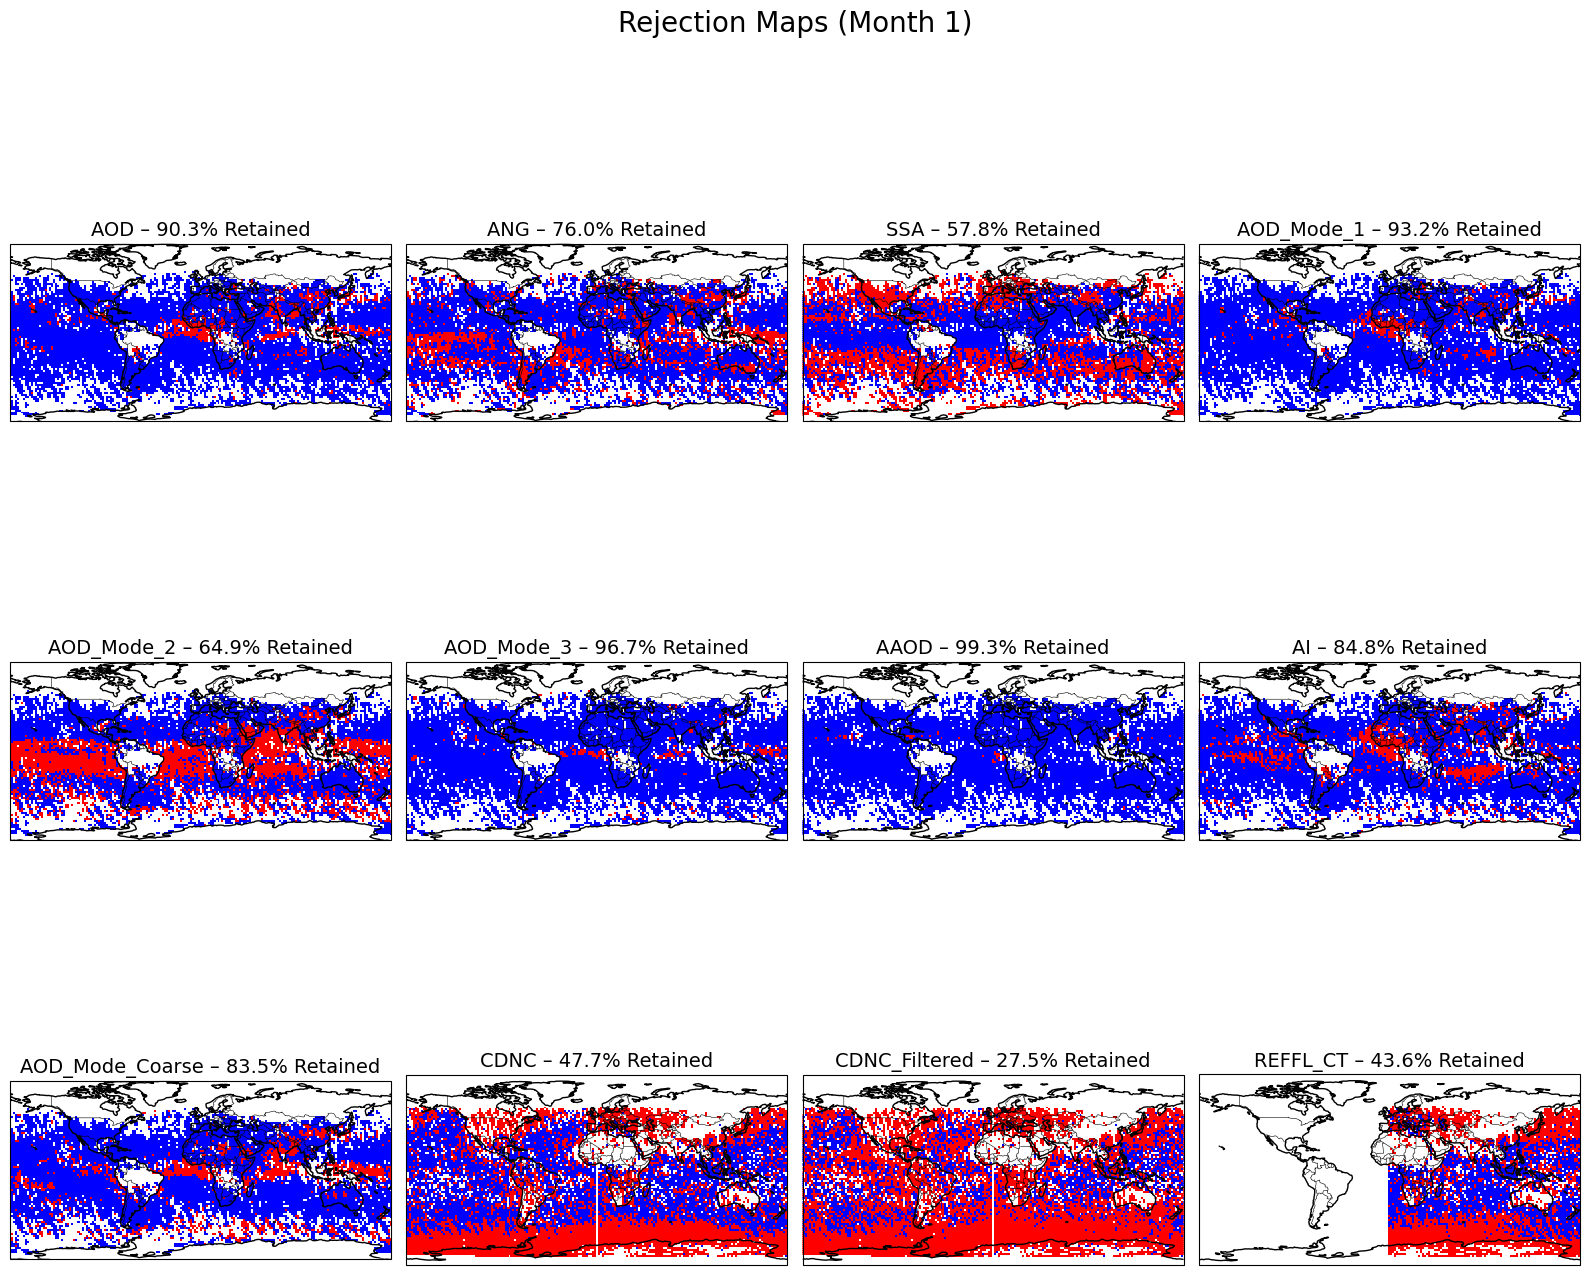

In [13]:
import xarray as xr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
vars_to_load = ["AOD", "ANG", "SSA", "AOD_Mode_1", "AOD_Mode_2", "AOD_Mode_3", "AAOD", "AI",
                "AOD_Mode_Coarse", "CDNC", "CDNC_Filtered", "REFFL_CT"]

# --- Compute valid mask for observations (for plotting consistency) ---
obs_map = {
    "AOD": AOD[:],
    "ANG": ANG[:],
    "SSA": SSA[:],
    "AOD_Mode_1": AOD_m_1[:],
    "AOD_Mode_2": AOD_m_2[:],
    "AOD_Mode_3": AOD_m_1[:],
    "AI": (AI[:]),   # if this is your defined AI
    "AOD_Mode_Coarse": AOD_coarse[:],
    "CDNC": CDNC_OCI[:],
    "AAOD": AAOD[:],
    "CDNC_Filtered": CDNC_Filtered[:],
    "REFFL_CT": REFFL_CT[:],

}
month_to_plot = 1
base_dir = Path("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var")

# ---------------------------------------
# LOAD REJECTION MAPS
# ---------------------------------------
reject_maps = {}
n_samples_map = 50000
for var in vars_to_load:
    reject_path = base_dir / var / f"reject_map_{var.lower()}_{n_samples_map}.nc"
    ds = xr.open_dataset(reject_path)

    rm = ds["reject_mask"]

    # If reject_mask has sample dimension, average over samples
    if "sample" in rm.dims:
        rm = rm.mean("sample")

    # Select single month if month exists
    if "month" in rm.dims:
        rm = rm.sel(month=month_to_plot)

    # Boolean mask (1 rejected, 0 retained)
    reject_maps[var] = rm > 0.5

# ---------------------------------------
# APPLY OBSERVATION MASK (WHITE WHERE MISSING OBS)
# ---------------------------------------
def apply_obs_mask(reject_bool, var):
    obs = obs_map[var]

    # If observation has month dimension
    if "month" in obs.dims:
        obs_m = obs.sel(month=month_to_plot)
    else:
        obs_m = obs

    # Missing obs -> NaN mask
    mask = xr.where(np.isnan(obs_m), np.nan, 1)

    # Apply mask: rejected=1, retained=0, missing=nan
    return reject_bool * mask

masked_reject_maps = {var: apply_obs_mask(reject_maps[var], var) for var in vars_to_load}

# ---------------------------------------
# COMPUTE % REJECTED
# ---------------------------------------
reject_percent = {}
for var in vars_to_load:
    arr = masked_reject_maps[var]
    num_rejected = np.nansum(arr).item()
    total = np.count_nonzero(~np.isnan(arr))
    reject_percent[var] = (num_rejected / total) * 100
    print(f"{var}: {reject_percent[var]:.1f}% Retained")

# ---------------------------------------
# PLOTTING
# ---------------------------------------
n = len(vars_to_load)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig = plt.figure(figsize=(16, 5 * nrows))

for i, var in enumerate(vars_to_load, 1):
    arr = masked_reject_maps[var]
    arr = arr.assign_coords(lon=(((arr.lon + 180) % 360) - 180))
    arr = arr.sortby("lon")

    ax = plt.subplot(nrows, ncols, i, projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    img = ax.pcolormesh(
        arr.lon, arr.lat,
        arr,
        cmap="bwr_r",
        shading="nearest",
        vmin=0, vmax=1
    )
    img.cmap.set_bad(color="white")   # White = missing observations

    ax.set_title(f"{var} – {reject_percent[var]:.1f}% Retained", fontsize=14)

fig.suptitle(f"Rejection Maps (Month {month_to_plot})", fontsize=20)
plt.tight_layout()
plt.show()


102026 and 49.2% constrainable variables for AOD (True only)
91402 and 44.1% constrainable variables for ANG (True only)
20772 and 10.0% constrainable variables for SA (True only)
106917 and 51.6% constrainable variables for AAOD (True only)
104770 and 50.5% constrainable variables for AOD Mode 1 (True only)
75541 and 36.4% constrainable variables for AOD Mode 2 (True only)
108647 and 52.4% constrainable variables for AOD Mode 3 (True only)


/scratch-local/ybhatti2.15709792/ipykernel_3559261/2961226000.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.92])


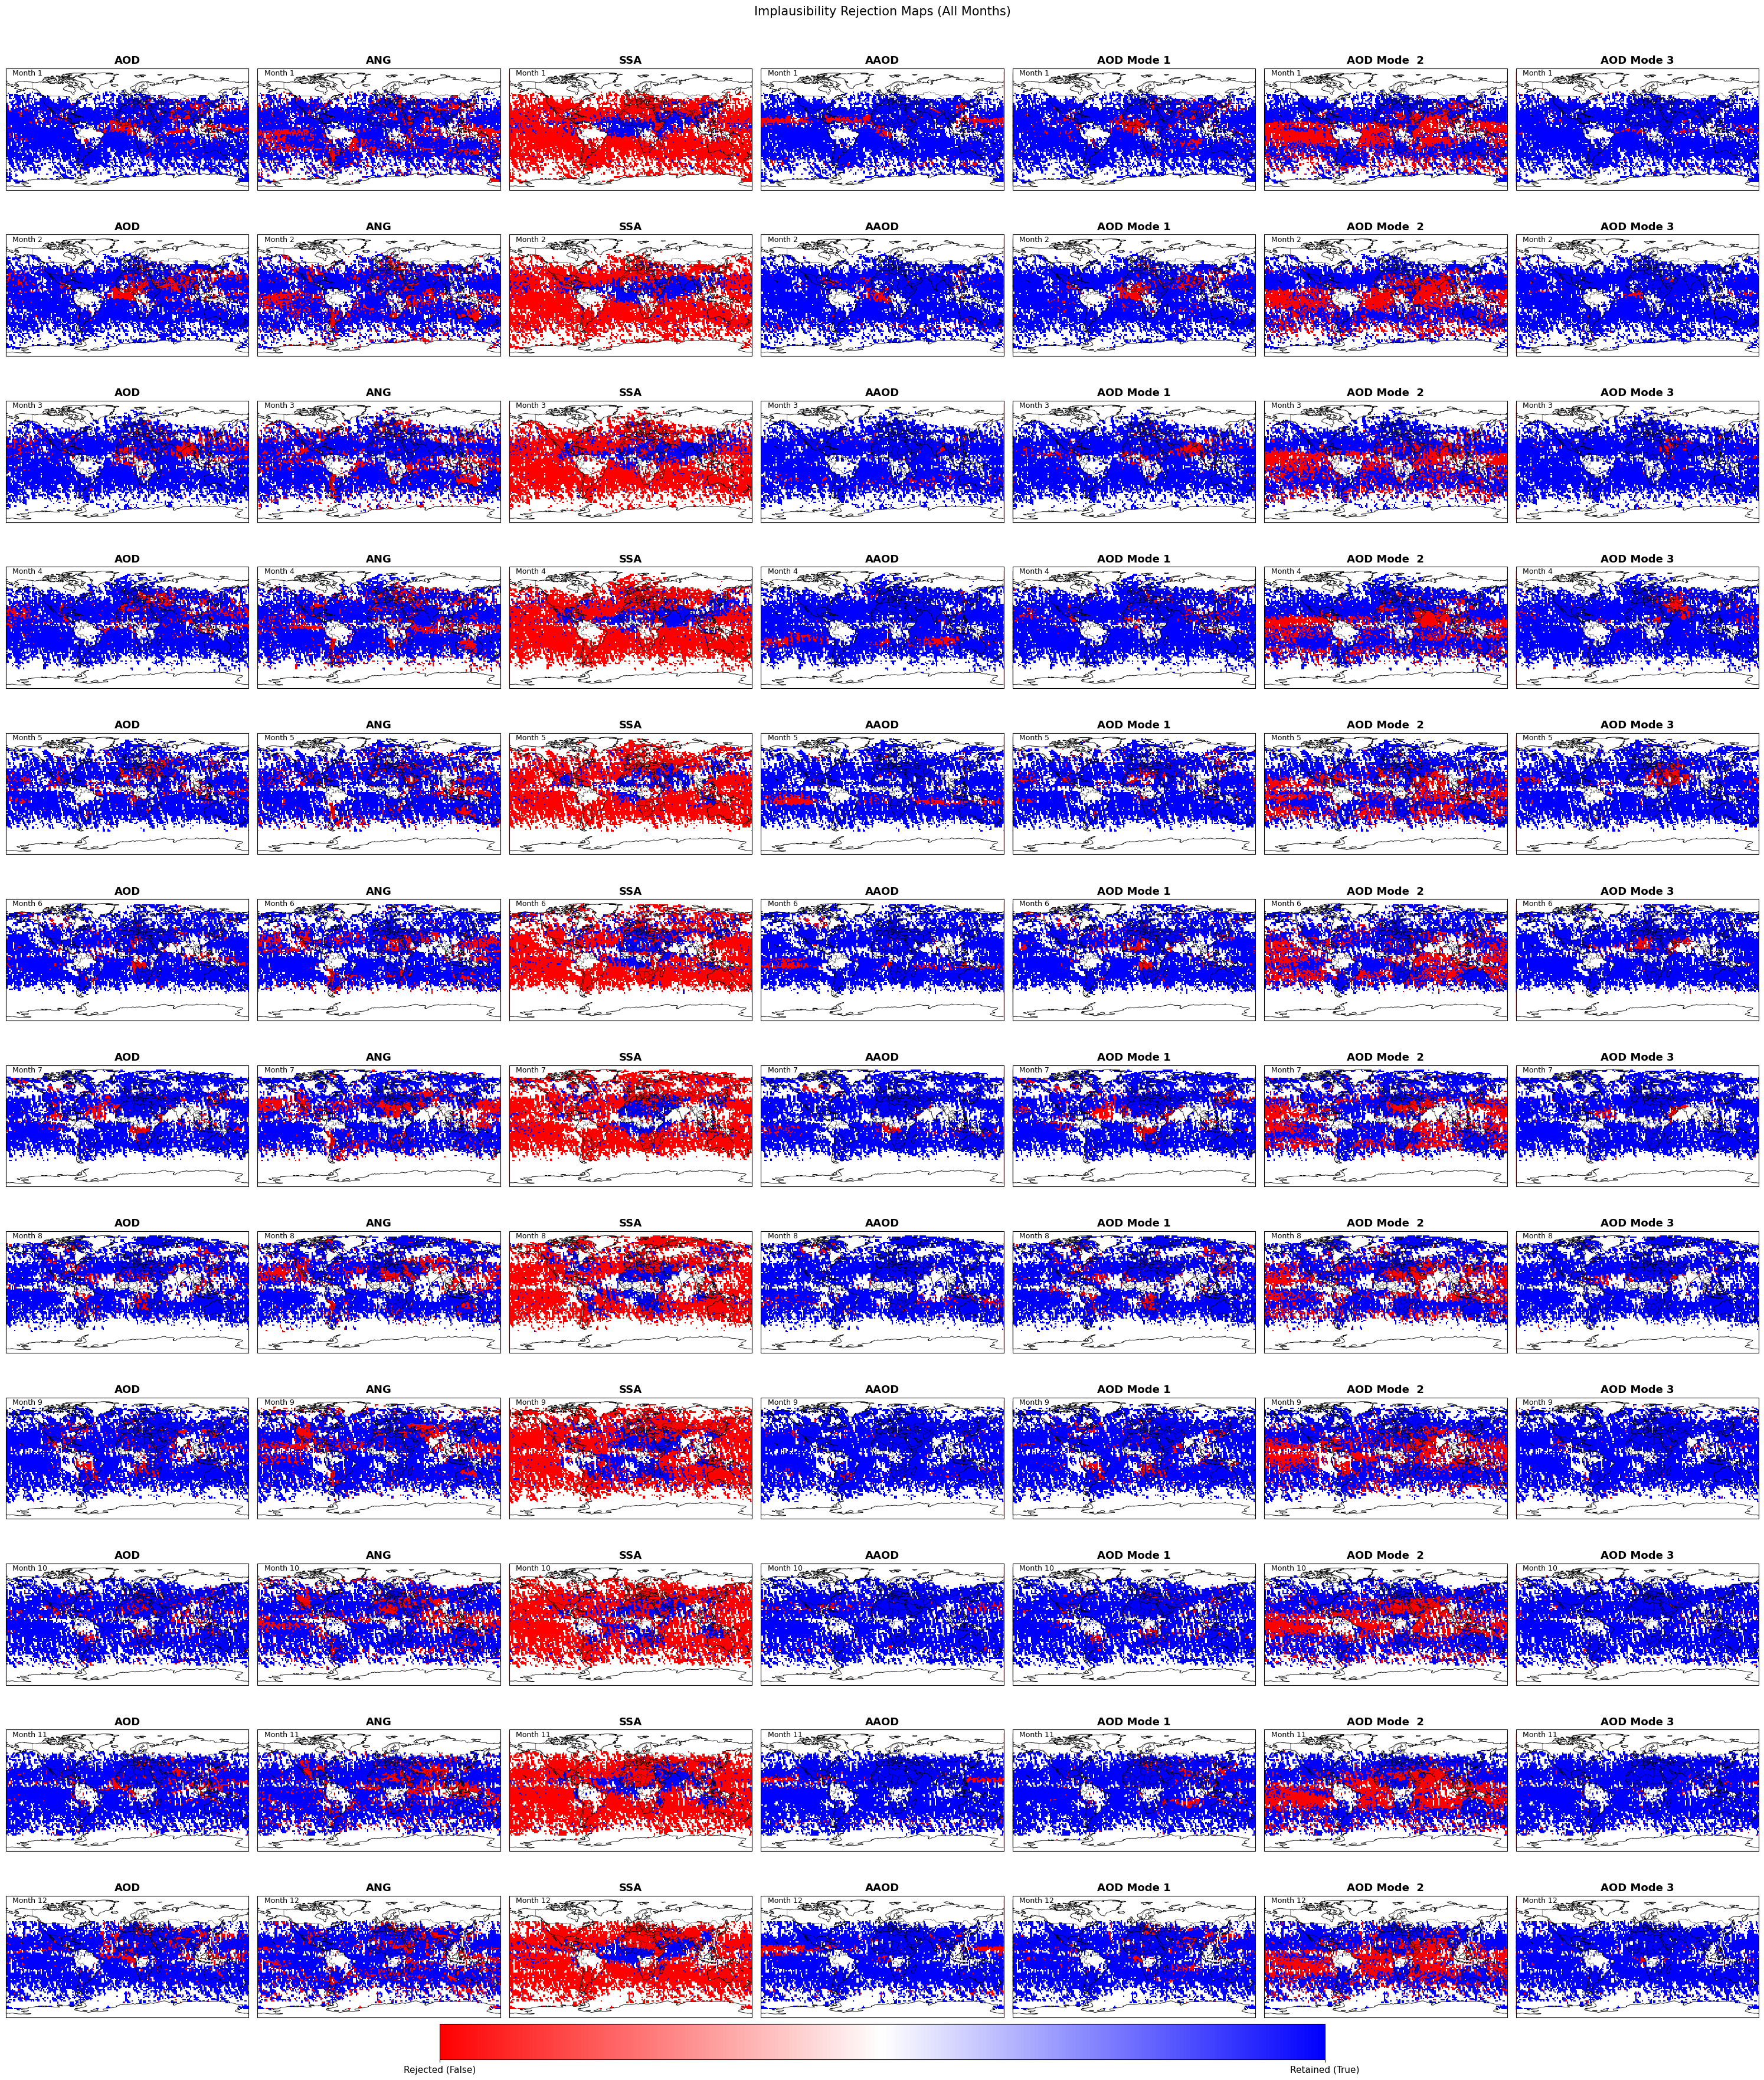

In [16]:
# # # --- Convert da_masked (where NaN = False, valid = True) ---
# reject_map_aod_imp = ~np.isnan(implaus_mask_aod.mean('sample'))
# print(f"{reject_map_aod_imp.sum().item()} and {(reject_map_aod_imp.sum().item()/reject_map_aod_imp.size) * 100:.1f}% constrainable variables for AOD (True only)")

# reject_map_ang_imp = ~np.isnan(implaus_mask_ang.mean('sample'))
# print(f"{reject_map_ang_imp.sum().item()} and {(reject_map_ang_imp.sum().item()/reject_map_ang_imp.size) * 100:.1f}% constrainable variables for ANG (True only)")

# reject_map_ssa_imp = ~np.isnan(implaus_mask_ssa.mean('sample'))
# print(f"{reject_map_ssa_imp.sum().item()} and {(reject_map_ssa_imp.sum().item()/reject_map_ssa_imp.size) * 100:.1f}% constrainable variables for SA (True only)")

# reject_map_aaod_imp = ~np.isnan(implaus_mask_aaod.mean('sample'))
# print(f"{reject_map_aaod_imp.sum().item()} and {(reject_map_aaod_imp.sum().item()/reject_map_aaod_imp.size) * 100:.1f}% constrainable variables for AAOD (True only)")

# reject_map_aod_mode_1_imp = ~np.isnan(implaus_mask_aod_mode_1.mean('sample'))
# print(f"{reject_map_aod_mode_1_imp.sum().item()} and {(reject_map_aod_mode_1_imp.sum().item()/reject_map_aod_mode_1_imp.size) * 100:.1f}% constrainable variables for AOD Mode 1 (True only)")

# reject_map_aod_mode_2_imp = ~np.isnan(implaus_mask_aod_mode_2.mean('sample'))
# print(f"{reject_map_aod_mode_2_imp.sum().item()} and {(reject_map_aod_mode_2_imp.sum().item()/reject_map_aod_mode_2_imp.size) * 100:.1f}% constrainable variables for AOD Mode 2 (True only)")

# reject_map_aod_mode_3_imp = ~np.isnan(implaus_mask_aod_mode_3.mean('sample'))
# print(f"{reject_map_aod_mode_3_imp.sum().item()} and {(reject_map_aod_mode_3_imp.sum().item()/reject_map_aod_mode_3_imp.size) * 100:.1f}% constrainable variables for AOD Mode 3 (True only)")

# reject_maps_imp = {}
# for var in implaus_masks:
#     reject_maps_imp[var] = ~np.isnan(implaus_masks[var].mean('sample'))
#     n_true = reject_maps_imp[var].sum().item()
#     pct_true = (n_true / reject_maps_imp[var].size) * 100
#     print(f"{n_true} and {pct_true:.1f}% constrainable variables for {var} (True only)")

# # --- Setup figure for 12 months (2 columns: AOD left, ANG right) ---
# fig, axes = plt.subplots(
#     nrows=12, ncols=7, figsize=(30, 40),
#     subplot_kw={"projection": ccrs.PlateCarree()}
# )

# for i, month in enumerate(range(1, 13)):
#     for j, (reject_map, title) in enumerate(zip(
#         [reject_map_aod_imp, reject_map_ang_imp, reject_map_ssa_imp, reject_map_aaod_imp, reject_map_aod_mode_1_imp, reject_map_aod_mode_2_imp, reject_map_aod_mode_3_imp],
#         ["AOD", "ANG", "SSA", "AAOD", "AOD Mode 1", "AOD Mode  2", "AOD Mode 3"]
#     )):
#         ax = axes[i, j]
#         ax.coastlines(resolution="110m", linewidth=0.6)
#         ax.add_feature(cfeature.BORDERS, linewidth=0.3)
#         ax.set_global()
#         ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

#         #if i == 0:
#         ax.set_title(title, fontsize=13, fontweight="bold")
#         ax.text(-170, 80, f"Month {month}", fontsize=9, ha="left")

#         # Select monthly map
#         rm = reject_map.sel(month=month)
#         vm = valid_mask.sel(month=month)

#         # Plot retained (True=blue) vs rejected (False=red)
#         img = ax.pcolormesh(
#             rm.lon, rm.lat, rm.astype(int),
#             cmap="bwr_r", vmin=0, vmax=1,
#             transform=ccrs.PlateCarree()
#         )

#         # --- Mask invalid (False/NaN) pixels only and plot white ---
#         invalid_mask = ~vm
#         invalid_mask = invalid_mask.where(invalid_mask, np.nan)  # keep only False cells
#         ax.pcolormesh(
#             rm.lon, rm.lat, invalid_mask,
#             cmap="Greys_r", vmin=0, vmax=1,
#             transform=ccrs.PlateCarree(),
#             alpha=1.0
#         )

# # --- Shared colorbar ---
# cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.015])
# cbar = plt.colorbar(img, cax=cbar_ax, orientation='horizontal', ticks=[0, 1])
# cbar.ax.set_xticklabels(["Rejected (False)", "Retained (True)"])
# cbar.ax.tick_params(labelsize=11)

# plt.suptitle("Implausibility Rejection Maps (All Months)", fontsize=15, y=0.92)
# plt.tight_layout(rect=[0, 0.05, 1, 0.92])
# #plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/Implausible_Map_Reject.png",dpi=100,bbox_inches = 'tight')
# plt.show()


In [21]:
from pathlib import Path

# --- Configuration ---
n_samples = 100000  # You can easily change this once at the top

base_dir = Path("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional")
vars_to_load = ["AOD", "ANG", "SSA", "AOD_Mode_1", "AOD_Mode_2", "AOD_Mode_3", "AAOD", "AI",
                "AOD_Mode_Coarse", "CDNC", "CDNC_Filtered", "REFFL_CT"]

ppe_normalized_new_samples = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples}.csv')
#ppe_normalized_new_samples = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples}_Important_Parameters.csv')
ppe_normalized_new_samples.set_index(ppe_normalized_new_samples.columns[0], inplace=True)

ppe_path = base_dir / f"../ppe_params_non_norm_{n_samples}.csv"
#ppe_path = base_dir / f"../ppe_params_non_norm_{n_samples}_Important_Parameters.csv"
ppe_non_normalized_new_samples = pd.read_csv(ppe_path)
ppe_non_normalized_new_samples.set_index(ppe_non_normalized_new_samples.columns[0], inplace=True)

# --- Containers ---
regional_data = {}
boxplot_data = {}
ppe_params = None
#base_dir = Path("/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/New_Error_Map")

# --- Load variable data efficiently ---
for var in vars_to_load:
    var_dir = base_dir / var

    # Regional Uncertainty files
    reg_file = var_dir / f"emulated_{var.lower()}_{n_samples}.nc"
#    reg_file = var_dir / f"emulated_{var.lower()}_{n_samples}_Important_Parameters.nc"

 #   end
   # box_file = var_dir / f"Boxplot_Unconstrained_Uncertainty_{var.lower()}_{n_samples}.nc"
    try:
        with xr.open_dataset(reg_file) as ds_reg:
            # Extract variable by name dynamically
            regional_data[var] = ds_reg[f"Emulated {var}"]
        # with xr.open_dataset(box_file) as ds_box:
            #boxplot_data[var] = ds_box.to_array().squeeze().mean('month')
            boxplot_data[var] = ds_reg[f"Emulated {var}"].mean('month')#, skipna=True)
            #boxplot_data[var] = boxplot_data[var].reset_coords(drop=True).drop_vars('variable', errors='ignore')
    except:
        print(f"⚠️ Missing: {var}")

# --- Load PPE parameters ---

regional_dataset = xr.Dataset({
    "AOD": regional_data["AOD"],
    "ANG": regional_data["ANG"],
    "SSA": regional_data["SSA"],
    "AAOD": regional_data["AAOD"],
    "AOD_Mode_1": regional_data["AOD_Mode_1"],
    "AOD_Mode_2": regional_data["AOD_Mode_2"],
    "AOD_Mode_3": regional_data["AOD_Mode_3"],
    "AI": regional_data["AI"],
    "AOD_Mode_Coarse": regional_data["AOD_Mode_Coarse"],
    "CDNC": regional_data["CDNC"],
    "CDNC_Filtered": regional_data["CDNC_Filtered"],
    "REFFL_CT": regional_data["REFFL_CT"],


})

boxplot_dataset = xr.Dataset({
    "AOD": boxplot_data["AOD"],
    "ANG": boxplot_data["ANG"],
    "SSA": boxplot_data["SSA"],
    "AAOD": boxplot_data["AAOD"],
    "AOD_Mode_1": boxplot_data["AOD_Mode_1"],
    "AOD_Mode_2": boxplot_data["AOD_Mode_2"],
    "AOD_Mode_3": boxplot_data["AOD_Mode_3"],
    "AI": boxplot_data["AI"],
    "AOD_Mode_Coarse": boxplot_data["AOD_Mode_Coarse"],
    "CDNC": boxplot_data["CDNC"],
    "CDNC_Filtered": boxplot_data["CDNC_Filtered"],
    "REFFL_CT": boxplot_data["REFFL_CT"],


})

regional_dataset = regional_dataset.where(regional_dataset != 0, np.nan)
boxplot_dataset = boxplot_dataset.where(boxplot_dataset != 0, np.nan)


region_names = [
    'Australia', 'Europe', 'South-East Asia', 'Siberia','Savannah',
    'North America', 'Boreal America',
    'Amazon', 'North Atlantic', 'South Atlantic', 'North Pacific',
    'South Pacific', 'Tropic Atlantic' , 'Tropic Pacific', 'Tropic Indian', 'South Indian',
    'Dust belt','Shipping', 'Global'
]

Combined_Uncertainty_Contribution = pd.read_csv('/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/All_Uncertainty_Contributions.csv')



In [22]:
#Lets try trying extreme regions :
regional_dataset_aaod = regional_dataset.AAOD[:].where(~regional_dataset.region.isin(["North Atlantic", "South Atlantic","North Pacific",
                                                                                   "South Pacific","Tropic Atlantic", "Tropic Pacific",
                                                                                   "Tropic Indian", "South Indian"]), drop=True)
regional_dataset_ssa = regional_dataset.SSA[:].where(~regional_dataset.region.isin(["North Atlantic", "South Atlantic","North Pacific",
                                                                                   "South Pacific","Tropic Atlantic", "Tropic Pacific",
                                                                                   "Tropic Indian", "South Indian"]), drop=True)


constrainable_AOD = regional_dataset.AOD.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_ANG = regional_dataset.ANG.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_SSA = regional_dataset.SSA.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_AAOD = regional_dataset.AAOD.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_AOD_Mode_1 = regional_dataset.AOD_Mode_1.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_AOD_Mode_2 = regional_dataset.AOD_Mode_2.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_AOD_Mode_3 = regional_dataset.AOD_Mode_3.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_AI = regional_dataset.AI.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_AOD_Mode_Coarse = regional_dataset.AOD_Mode_Coarse.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_CDNC = regional_dataset.CDNC.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_CDNC_Filtered = regional_dataset.CDNC_Filtered.stack(z=("region","month")).dropna(dim="z", how="any")
constrainable_REFFL_CT = regional_dataset.REFFL_CT.stack(z=("region","month")).dropna(dim="z", how="any")

# We then need to compute the absolute difference between ensemble to obs for each ensemble member:

Abs_Diff_AOD = abs(constrainable_AOD[:len(constrainable_AOD.sample)-1] - constrainable_AOD[-1])
Abs_Diff_ANG = abs(constrainable_ANG[:len(constrainable_ANG.sample)-1] - constrainable_ANG[-1])
Abs_Diff_SSA = abs(constrainable_SSA[:len(constrainable_SSA.sample)-1] - constrainable_SSA[-1])
Abs_Diff_AAOD = abs(constrainable_AAOD[:len(constrainable_AAOD.sample)-1] - constrainable_AAOD[-1])
Abs_Diff_AOD_Mode_1 = abs(constrainable_AOD_Mode_1[:len(constrainable_AOD_Mode_1.sample)-1] - constrainable_AOD_Mode_1[-1])
Abs_Diff_AOD_Mode_2 = abs(constrainable_AOD_Mode_2[:len(constrainable_AOD_Mode_2.sample)-1] - constrainable_AOD_Mode_2[-1])
Abs_Diff_AOD_Mode_3 = abs(constrainable_AOD_Mode_3[:len(constrainable_AOD_Mode_3.sample)-1] - constrainable_AOD_Mode_3[-1])
Abs_Diff_AI = abs(constrainable_AI[:len(constrainable_AI.sample)-1] - constrainable_AI[-1])
Abs_Diff_AOD_Mode_Coarse = abs(constrainable_AOD_Mode_Coarse[:len(constrainable_AOD_Mode_Coarse.sample)-1] - constrainable_AOD_Mode_Coarse[-1])
Abs_Diff_CDNC = abs(constrainable_CDNC[:len(constrainable_CDNC.sample)-1] - constrainable_CDNC[-1])
Abs_Diff_CDNC_Filtered = abs(constrainable_CDNC_Filtered[:len(constrainable_CDNC_Filtered.sample)-1] - constrainable_CDNC_Filtered[-1])
Abs_Diff_REFFL_CT = abs(constrainable_REFFL_CT[:len(constrainable_REFFL_CT.sample)-1] - constrainable_REFFL_CT[-1])

obs_AOD = constrainable_AOD[-1]                     # observation
obs_AAOD = constrainable_AAOD[-1]                     # observation
obs_AOD_mode_1 = constrainable_AOD_Mode_1[-1]                     # observation
obs_AOD_mode_2 = constrainable_AOD_Mode_2[-1]                     # observation
obs_AOD_mode_3 = constrainable_AOD_Mode_3[-1]                     # observation
obs_AI = constrainable_AI[-1]                     # observation
obs_AOD_mode_Coarse = constrainable_AOD_Mode_Coarse[-1]                     # observation
obs_CDNC = constrainable_CDNC[-1]                     # observation
obs_CDNC_Filtered = constrainable_CDNC_Filtered[-1]                     # observation
obs_REFFL_CT = constrainable_REFFL_CT[-1]                     # observation


In [291]:


# # We need to stack region and month so that each ensemble member * 216.

# # --- AOD: compute threshold per grid cell (max of 0.02 or 10%) ---

# #threshold_AOD = xr.ufuncs.maximum(0.04, 0.2 * obs_AOD)  # element-wise max
# threshold_AOD = xr.ufuncs.maximum(0.035, 0.15 * obs_AOD)  # element-wise max
# threshold_AAOD = xr.ufuncs.maximum(0.0035, 0.15 * obs_AAOD)  # element-wise max
# threshold_AOD_mode_1 = xr.ufuncs.maximum(0.038, 0.10 * obs_AOD_mode_1)  # element-wise max
# threshold_AOD_mode_1 = xr.ufuncs.maximum(0.027, 0.10 * obs_AOD_mode_1) 
# threshold_AOD_mode_2 = xr.ufuncs.maximum(0.017, 0.05 * obs_AOD_mode_2)  # element-wise max
# threshold_AOD_mode_3 = xr.ufuncs.maximum(0.019, 0.05 * obs_AOD_mode_3)  # element-wise max
# threshold_AI = xr.ufuncs.maximum(0.027, 0.10 * obs_AI)  # element-wise max
# #threshold_AI = xr.ufuncs.maximum(0.022, 0.1 * obs_AI) 
# threshold_AOD_mode_Coarse = xr.ufuncs.maximum(0.018, 0.10 * obs_AOD_mode_Coarse)  # element-wise max
# threshold_CDNC = (0.3 * obs_CDNC) 

# fraction_per_sample_aod = (Abs_Diff_AOD < threshold_AOD).mean(dim="z")
# fraction_per_sample_ang = (Abs_Diff_ANG < 0.17).mean(dim="z")
# fraction_per_sample_aaod = (Abs_Diff_AAOD < threshold_AAOD).mean(dim="z")
# fraction_per_sample_ssa = (Abs_Diff_SSA < 0.035).mean(dim="z")
# fraction_per_sample_aod_mode_1 = (Abs_Diff_AOD_Mode_1 < threshold_AOD_mode_1).mean(dim="z")
# fraction_per_sample_aod_mode_2 = (Abs_Diff_AOD_Mode_2 < threshold_AOD_mode_2).mean(dim="z")
# fraction_per_sample_aod_mode_3 = (Abs_Diff_AOD_Mode_3 < threshold_AOD_mode_3).mean(dim="z")
# fraction_per_sample_ai = (Abs_Diff_AI < threshold_AI).mean(dim="z")
# fraction_per_sample_aod_mode_coarse = (Abs_Diff_AOD_Mode_Coarse < threshold_AOD_mode_Coarse).mean(dim="z")
# fraction_per_sample_cdnc = (Abs_Diff_CDNC < threshold_CDNC).mean(dim="z")

# #fraction_per_sample_ang = (Abs_Diff_ANG < 0.2).mean(dim="z")

# # test = xr.concat(fraction_per_sample_ang,fraction_per_sample_aod, fraction_per_sample_ssa, 
# #                 fraction_per_sample_aod_mode_1, fraction_per_sample_aod_mode_2, fraction_per_sample_aod_mode_3, fraction_per_sample_ai)
# # test = xr.concat(test,fraction_per_sample_ssa)
# test = xr.concat(
#     [
#         fraction_per_sample_ang,
#         fraction_per_sample_aod,
#         fraction_per_sample_ssa,
#         # fraction_per_sample_aod_mode_1,
#         # fraction_per_sample_aod_mode_2,
#         # fraction_per_sample_aod_mode_3,
#         fraction_per_sample_ai,
#     ],
#     dim="variable"
# )

# # accepted_overall = test > 0.67

# # --- Identify accepted samples (where > 67% of z-points are within threshold) ---
# accepted_aod = fraction_per_sample_aod > 0.67
# accepted_ang = fraction_per_sample_ang > 0.67
# accepted_ssa= fraction_per_sample_ssa> 0.67
# accepted_aaod= fraction_per_sample_aaod> 0.67
# accepted_aod_mode_1= fraction_per_sample_aod_mode_1> 0.67
# accepted_aod_mode_2= fraction_per_sample_aod_mode_2> 0.67
# accepted_aod_mode_3= fraction_per_sample_aod_mode_3> 0.67
# accepted_ai = fraction_per_sample_ai > 0.67
# accepted_aod_mode_coarse = fraction_per_sample_aod_mode_coarse> 0.67
# accepted_cdnc = fraction_per_sample_cdnc > 0.67


# accepted_test = test > 0.67

# # --- Combine: only accept samples passing both AOD and ANG constraints ---
# accepted_both = accepted_aod & accepted_ang & accepted_ssa
# accepted_both = accepted_aod & accepted_ang & accepted_aaod

# accepted_both = accepted_aod & accepted_ssa & accepted_ai & accepted_aod_mode_1 &  accepted_aod_mode_2  & accepted_aod_mode_3 
# accepted_both = accepted_aod_mode_2 & accepted_ssa  & accepted_cdnc

# accepted_overall = test > 0.67

# # --- Compute final percentage ---
# accepted_pct = 100 * accepted_both.sum().item() / accepted_both.size
# accepted_pct_overall = 100 * accepted_overall.sum().item() / accepted_overall.size

# print(f"Accepted AOD-only = {(accepted_aod.sum().item() / accepted_aod.size) * 100:.2f}%")
# print(f"Accepted ANG-only = {(accepted_ang.sum().item() / accepted_ang.size) * 100:.2f}%")
# print(f"Accepted SSA-only = {(accepted_ssa.sum().item() / accepted_ssa.size) * 100:.2f}%")
# print(f"Accepted AAOD-only = {(accepted_aaod.sum().item() / accepted_aaod.size) * 100:.2f}%")
# print(f"Accepted AOD_MODE_1-only = {(accepted_aod_mode_1.sum().item() / accepted_aod_mode_1.size) * 100:.2f}%")
# print(f"Accepted AOD_MODE_2-only = {(accepted_aod_mode_2.sum().item() / accepted_aod_mode_2.size) * 100:.2f}%")
# print(f"Accepted AOD_MODE_3-only = {(accepted_aod_mode_3.sum().item() / accepted_aod_mode_3.size) * 100:.2f}%")
# print(f"Accepted AOD_MODE_Coarse-only = {(accepted_aod_mode_coarse.sum().item() / accepted_aod_mode_coarse.size) * 100:.2f}%")
# print(f"Accepted AI-only = {(accepted_ai.sum().item() / accepted_ai.size) * 100:.2f}%")
# print(f"Accepted CDNC-only = {(accepted_cdnc.sum().item() / accepted_cdnc.size) * 100:.2f}%")

# print(f"Accepted BOTH = {accepted_pct:.2f}%")
# #print(f"Accepted aod+ang togehter = {(accepted_overall.sum().item() / accepted_overall.size) * 100:.2f}%")
# print(f"TOTAL Number Accepted = {accepted_both.sum().item()} / {accepted_both.size}")
# #print(f"Accepted all togehter = {(accepted_overall.sum().item() / accepted_overall.size) * 100:.2f}%")


In [23]:


# We need to stack region and month so that each ensemble member * 216.

# --- AOD: compute threshold per grid cell (max of 0.02 or 10%) ---

#threshold_AOD = xr.ufuncs.maximum(0.04, 0.2 * obs_AOD)  # element-wise max
threshold_AOD = xr.ufuncs.maximum(0.035, 0.2 * obs_AOD)  # element-wise max
threshold_AAOD = xr.ufuncs.maximum(0.0035, 0.15 * obs_AAOD)  # element-wise max
threshold_AOD_mode_1 = xr.ufuncs.maximum(0.031, 0.10 * obs_AOD_mode_1)  # element-wise max
threshold_AOD_mode_2 = xr.ufuncs.maximum(0.018, 0.05 * obs_AOD_mode_2)  # element-wise max
threshold_AOD_mode_3 = xr.ufuncs.maximum(0.03, 0.1 * obs_AOD_mode_3)  # element-wise max
threshold_AI = xr.ufuncs.maximum(0.025, 0.1 * obs_AI)  # element-wise max
threshold_AOD_mode_Coarse = xr.ufuncs.maximum(0.027, 0.05 * obs_AOD_mode_Coarse)  # element-wise max
threshold_CDNC = (0.3 * obs_CDNC) 
threshold_CDNC_Filtered = (1.2 * obs_CDNC_Filtered) 
threshold_REFFL_CT = (0.21 * obs_REFFL_CT) 

fraction_per_sample_aod = (Abs_Diff_AOD < threshold_AOD).mean(dim="z")
fraction_per_sample_ang = (Abs_Diff_ANG < 0.18).mean(dim="z")
fraction_per_sample_aaod = (Abs_Diff_AAOD < threshold_AAOD).mean(dim="z")
fraction_per_sample_ssa = (Abs_Diff_SSA < 0.035).mean(dim="z")
fraction_per_sample_aod_mode_1 = (Abs_Diff_AOD_Mode_1 < threshold_AOD_mode_1).mean(dim="z")
fraction_per_sample_aod_mode_2 = (Abs_Diff_AOD_Mode_2 < threshold_AOD_mode_2).mean(dim="z")
fraction_per_sample_aod_mode_3 = (Abs_Diff_AOD_Mode_3 < threshold_AOD_mode_3).mean(dim="z")
fraction_per_sample_ai = (Abs_Diff_AI < threshold_AI).mean(dim="z")
fraction_per_sample_aod_mode_coarse = (Abs_Diff_AOD_Mode_Coarse < threshold_AOD_mode_Coarse).mean(dim="z")
fraction_per_sample_cdnc = (Abs_Diff_CDNC < threshold_CDNC).mean(dim="z")
fraction_per_sample_cdnc_filtered = (Abs_Diff_CDNC_Filtered < threshold_CDNC_Filtered).mean(dim="z")
fraction_per_sample_reffl_ct = (Abs_Diff_REFFL_CT < threshold_REFFL_CT).mean(dim="z")

# accepted_overall = test > 0.67

# --- Identify accepted samples (where > 67% of z-points are within threshold) ---
accepted_aod = fraction_per_sample_aod > 0.67
accepted_ang = fraction_per_sample_ang > 0.67
accepted_ssa= fraction_per_sample_ssa> 0.67
accepted_aaod= fraction_per_sample_aaod> 0.67
accepted_aod_mode_1= fraction_per_sample_aod_mode_1> 0.67
accepted_aod_mode_2= fraction_per_sample_aod_mode_2> 0.67
accepted_aod_mode_3= fraction_per_sample_aod_mode_3> 0.67
accepted_ai = fraction_per_sample_ai > 0.67
accepted_aod_mode_coarse = fraction_per_sample_aod_mode_coarse> 0.67
accepted_cdnc = fraction_per_sample_cdnc > 0.67
accepted_cdnc_filtered = fraction_per_sample_cdnc_filtered > 0.67
accepted_reffl_ct = fraction_per_sample_reffl_ct > 0.67

# --- Combine: only accept samples passing both AOD and ANG constraints ---
accepted_both = accepted_aod & accepted_ang & accepted_ssa
accepted_both = accepted_aod & accepted_ang & accepted_aaod

accepted_both = accepted_aod_mode_1 & accepted_aod_mode_2 &accepted_aod_mode_3 & accepted_aod & accepted_ang & accepted_ssa & accepted_aaod
accepted_both = accepted_aod_mode_1 & accepted_aod_mode_coarse &  accepted_ssa & accepted_ai & accepted_cdnc_filtered 

# --- Compute final percentage ---
accepted_pct = 100 * accepted_both.sum().item() / accepted_both.size
#accepted_pct_overall = 100 * accepted_overall.sum().item() / accepted_overall.size

print(f"Accepted AOD-only = {(accepted_aod.sum().item() / accepted_aod.size) * 100:.2f}%")
print(f"Accepted ANG-only = {(accepted_ang.sum().item() / accepted_ang.size) * 100:.2f}%")
print(f"Accepted SSA-only = {(accepted_ssa.sum().item() / accepted_ssa.size) * 100:.2f}%")
print(f"Accepted AAOD-only = {(accepted_aaod.sum().item() / accepted_aaod.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_1-only = {(accepted_aod_mode_1.sum().item() / accepted_aod_mode_1.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_2-only = {(accepted_aod_mode_2.sum().item() / accepted_aod_mode_2.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_3-only = {(accepted_aod_mode_3.sum().item() / accepted_aod_mode_3.size) * 100:.2f}%")
print(f"Accepted AI-only = {(accepted_ai.sum().item() / accepted_ai.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_coarse-only = {(accepted_aod_mode_coarse.sum().item() / accepted_aod_mode_coarse.size) * 100:.2f}%")
print(f"Accepted CDNC-only = {(accepted_cdnc.sum().item() / accepted_cdnc.size) * 100:.2f}%")
print(f"Accepted CDNC_Filtered-only = {(accepted_cdnc_filtered.sum().item() / accepted_cdnc_filtered.size) * 100:.2f}%")
print(f"Accepted reffl_ct-only = {(accepted_reffl_ct.sum().item() / accepted_reffl_ct.size) * 100:.2f}%")

print(f"Accepted BOTH = {accepted_pct:.2f}%")
#print(f"Accepted aod+ang togehter = {(accepted_overall.sum().item() / accepted_overall.size) * 100:.2f}%")
print(f"TOTAL Number Accepted = {accepted_both.sum().item()} / {accepted_both.size}")


Accepted AOD-only = 29.06%
Accepted ANG-only = 39.42%
Accepted SSA-only = 38.95%
Accepted AAOD-only = 22.94%
Accepted AOD_MODE_1-only = 27.17%
Accepted AOD_MODE_2-only = 52.74%
Accepted AOD_MODE_3-only = 72.45%
Accepted AI-only = 22.60%
Accepted AOD_MODE_coarse-only = 56.62%
Accepted CDNC-only = 39.55%
Accepted CDNC_Filtered-only = 42.49%
Accepted reffl_ct-only = 37.41%
Accepted BOTH = 1.29%
TOTAL Number Accepted = 1287 / 100001


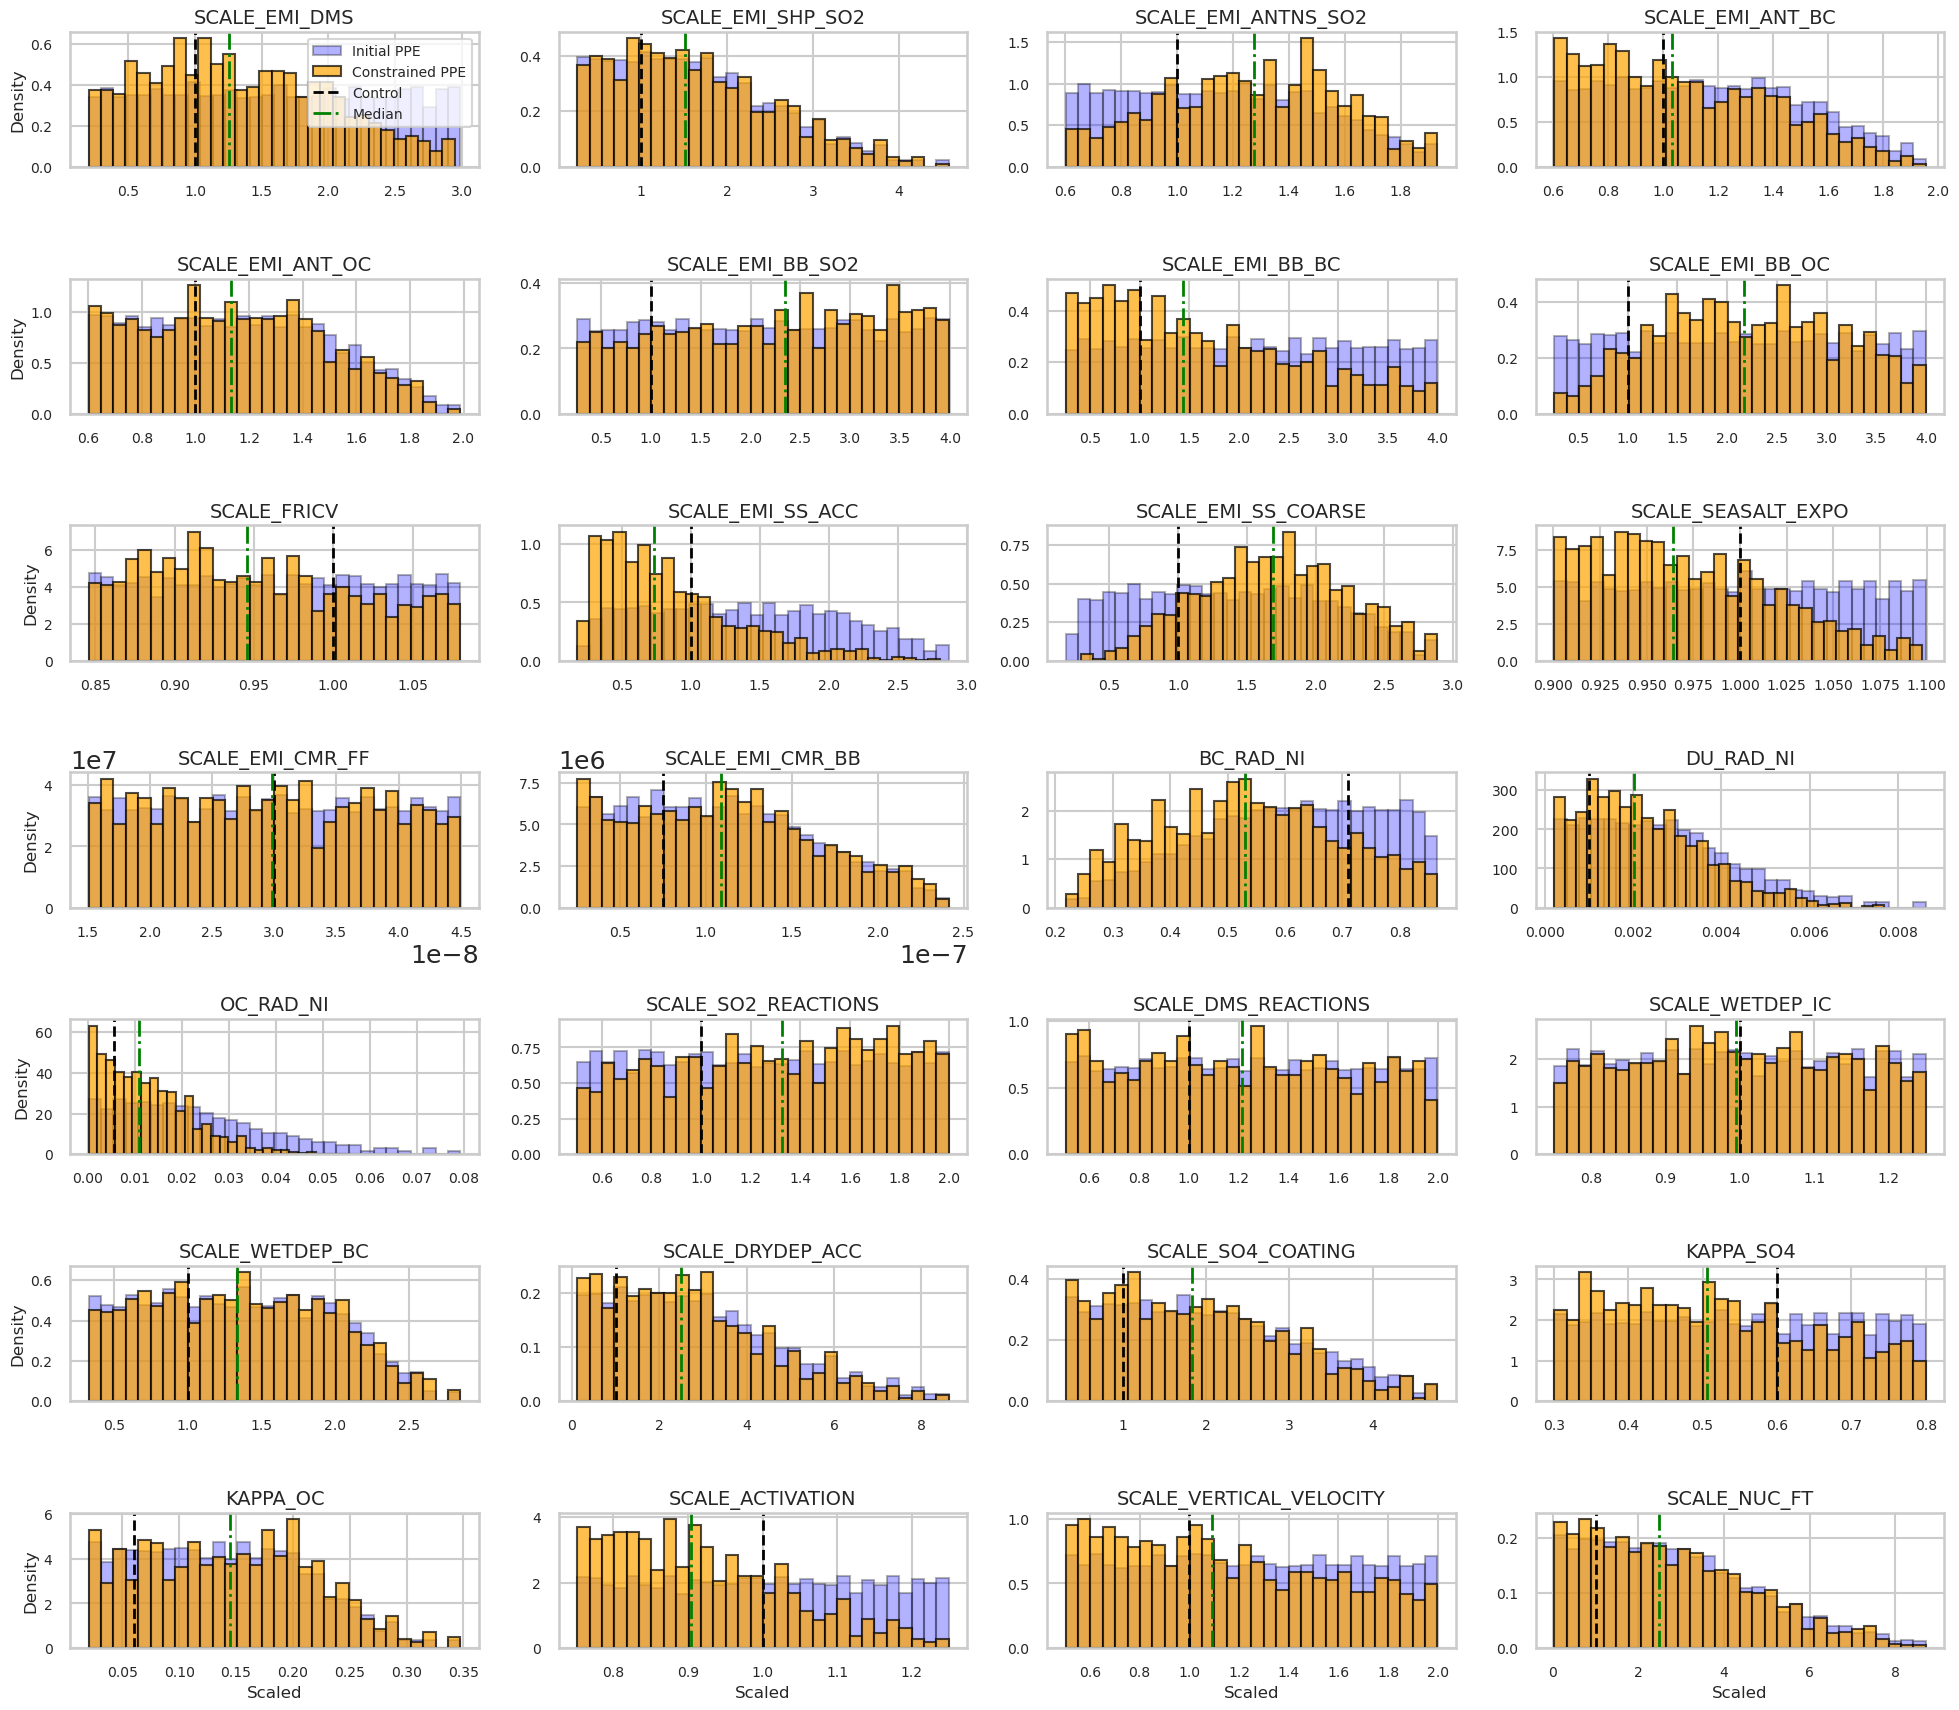

In [24]:
accepted_members_best = np.where(accepted_both)[0]  # indices where both conditions true

shared_dataset_Southern_Ocean = ppe_non_normalized_new_samples.iloc[accepted_members_best]
control_values = ppe_non_normalized_new_samples.iloc[0]
# best_member_values = ppe_non_normalized_new_samples.iloc[best_idx]
num_cols = len(shared_dataset_Southern_Ocean.columns)
cols_per_row = 4
rows = num_cols // cols_per_row + int(num_cols % cols_per_row > 0)

# First pass: compute max density across all plots
ymax = 0
for col in shared_dataset_Southern_Ocean.columns:
    # hist() with density=True returns n values
    n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
    n_shared, _, _ = plt.hist(shared_dataset_Southern_Ocean[col], bins=30, density=True)
    ymax = max(ymax, n_full.max(), n_shared.max())
plt.close()  # close the dummy figure

# Second pass: actual plotting
fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(20, rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(shared_dataset_Southern_Ocean.columns):
    ax = axes[i]

    # Histogram for full ensemble (blue, transparent)
    ppe_non_normalized_new_samples[col].hist(ax=ax, bins=30, edgecolor='black',
                          color='blue', alpha=0.3, label='Initial PPE', density=True)

    # Histogram for shared ensemble members (orange)
    shared_dataset_Southern_Ocean[col].hist(ax=ax, bins=30, edgecolor='black',
                             color='orange', alpha=0.7, label='Constrained PPE', density=True)

    # Vertical line for control value
    ax.axvline(control_values[col], color="black", linestyle="--", linewidth=2, label="Control")
    # ax.axvline(best_values[col], color="red", linestyle="--", linewidth=2, label="Best Ensemble")
    ax.axvline(shared_dataset_Southern_Ocean[col].median(), color="green", linestyle="dashdot", linewidth=2, label="Median")

    # Inside the plotting loop, after the control line:
    # ax.axvline(best_member_values[col], color='green', linestyle='-', linewidth=2, label='Best-fit')

    # Title for the subplot
    ax.set_title(col, fontsize=14)

    # y-axis label
    if i % cols_per_row != 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('Density', fontsize=12)

    # x-axis label
    if i < (rows - 1) * cols_per_row:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Scaled', fontsize=12)

    # Set same y-limits across all plots
   # ax.set_ylim(0, ymax * 1.1)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    if i == 0:
        ax.legend(fontsize=10)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/PPE_Distribution_Constrained.png", dpi=100, bbox_inches='tight')
#plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/PPE_Distribution_Constrained_Important.png", dpi=100, bbox_inches='tight')

plt.show()


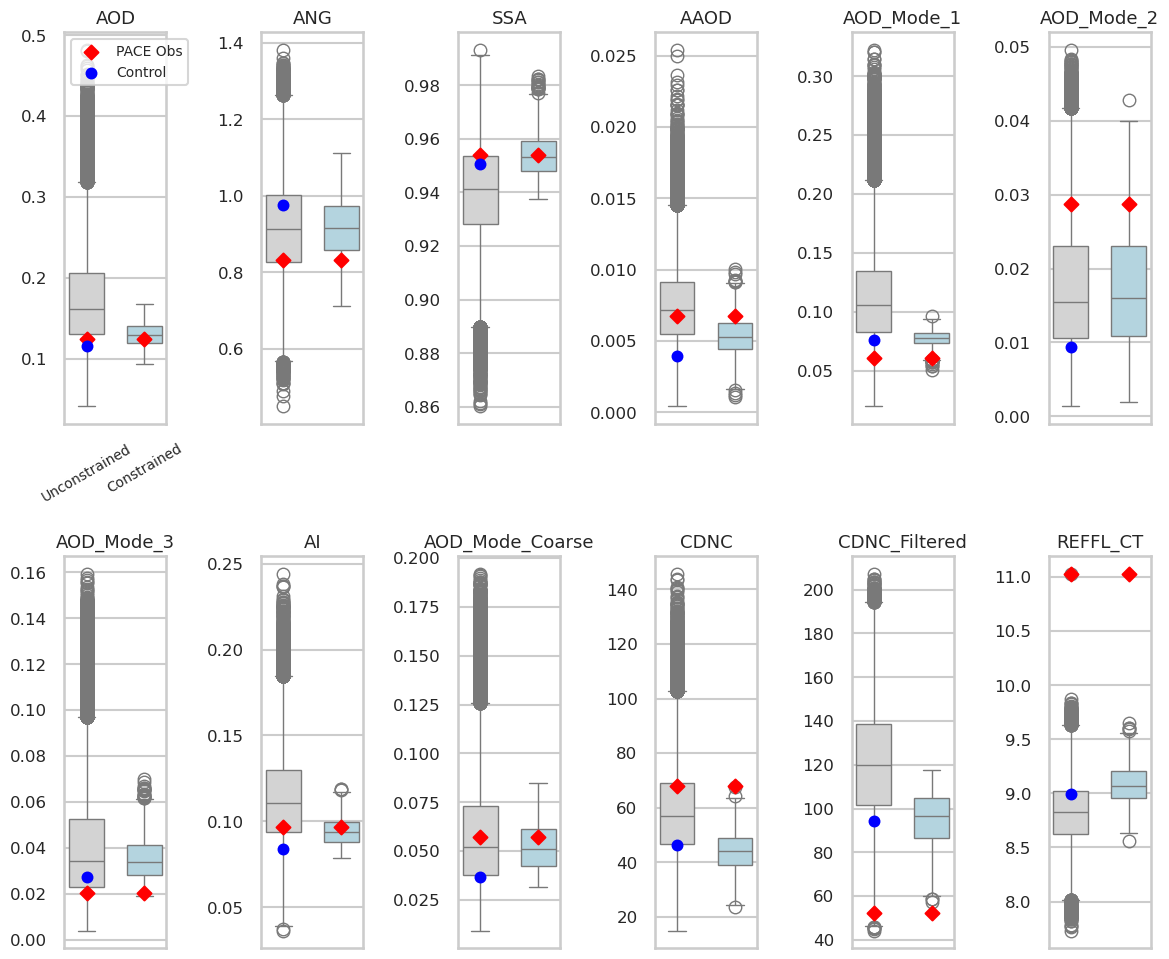

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# Variables to plot
variables = list(boxplot_dataset.data_vars)

# Example accepted ensembles: adjust according to your actual accepted samples
# Shape should be (n_samples_accepted, n_variables)
accepted_members_best = np.where(accepted_both)[0]  # indices where both conditions true

# --- Figure ---
n_vars = len(variables)
#fig, axes = plt.subplots(2, n_vars/2, figsize=(2*n_vars, 6), sharey=False)
n_cols = math.ceil(n_vars / 2)
fig, axes = plt.subplots(2, n_cols, figsize=(2*n_cols, 10), sharey=False)

#if n_vars == 1:
#    axes = [axes]
axes = axes.flatten()
plt.subplots_adjust(
    left=0.05, right=0.95,   # horizontal margins
    top=0.9, bottom=0.1,     # vertical margins
    wspace=0.1, hspace=0.4   # spacing between panels
)

for ax, var in zip(axes, variables):
    # Data for left boxplot: all samples
    data_total = boxplot_dataset[var].sel(region='Global').values
    # Data for right boxplot: only accepted
    data_accepted = boxplot_dataset[var].sel(region='Global').sel(sample=accepted_members_best).values

    # Combine into list for seaborn
    data_to_plot = [data_total, data_accepted]

    # Boxplot with positions 0 (total) and 1 (accepted)
    sns.boxplot(data=data_to_plot, ax=ax, width=0.6, palette=['lightgrey', 'lightblue'])
    
    # Overlay PACE observation (last sample in boxplot_dataset)
    obs_value = boxplot_dataset[var].sel(region='Global').values[-1]
    ax.scatter(0, obs_value, color='red', s=50, marker='D', label='PACE Obs', zorder=10)
    ax.scatter(1, obs_value, color='red', s=50, marker='D', zorder=10)  # also on accepted boxplot

    control_value = boxplot_dataset[var].sel(region='Global').values[0]
    ax.scatter(0, control_value, color='Blue', s=50, marker='o', label='Control', zorder=10)

    ax.set_xticks([0, 1])
   # ax.set_yticklabels(fontsize=10)
    ax.tick_params(axis='y', labelsize=12)  # smaller font for y-axis ticks
    ax.set_ylabel("", fontsize=10)  # smaller y-axis label

    ax.set_xticklabels(['Unconstrained', 'Constrained'], rotation=30, fontsize=10)
    ax.set_xticklabels(['',''], rotation=30, fontsize=10)
    ax.set_title(var, fontsize=13)
axes[0].set_xticklabels(['Unconstrained', 'Constrained'], rotation=30, fontsize=10)

# --- Legend (only once) ---
axes[0].legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/PPE_Observation_BOX_Unconstrained_vs_Constrained_Global.png", dpi=100, bbox_inches='tight')
#plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/PPE_Observation_BOX_Unconstrained_vs_Constrained_Global_Important_Parameter.png", dpi=100, bbox_inches='tight')

plt.show()


In [266]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=False)
# accepted_members_best = np.where(accepted_both)[0]  # indices where both conditions true

# #boxplot_dataset

# # --- Define both sets ---
# metrics_unconstrained = [
#     (boxplot_dataset['AOD'][:-1], boxplot_dataset['AOD'][-1], boxplot_dataset['AOD'][0], "AOD (550nm)", (-0.025, 0.4), np.linspace(0, 0.4, 5)),
#     (boxplot_data['ANG'][:-1], boxplot_data['ANG'][-1], boxplot_data['ANG'][0], "AE (550–865nm)", (0.25, 2), np.linspace(0.5, 2, 4)),
#     (boxplot_data['SSA'][:-1], boxplot_data['SSA'][-1], boxplot_data['SSA'][0], "SSA (550nm)", (0.75, 1), np.linspace(0.75, 1, 5)),
# ]

# metrics_constrained = [
#     (boxplot_dataset['AOD'][:-1].sel(sample=accepted_members_best), boxplot_dataset['AOD'][-1], boxplot_dataset['AOD'][0], "AOD Constrained (550nm)", (-0.025, 0.4), np.linspace(0, 0.4, 5)),
#     (boxplot_dataset['ANG'][:-1].sel(sample=accepted_members_best), boxplot_dataset['ANG'][-1], boxplot_dataset['ANG'][0], "AE Constrained (550–865nm)", (0.25, 2), np.linspace(0.5, 2, 4)),
#     (boxplot_dataset['SSA'][:-1].sel(sample=accepted_members_best), boxplot_dataset['SSA'][-1], boxplot_dataset['SSA'][0], "SSA Constrained (550nm)", (0.75, 1), np.linspace(0.75, 1, 5)),
# ]
# #    (boxplot_data_aod, polder_means_aod, boxplot_data_aod_control, "AOD Constrained (550nm)", (-0.025, 0.4), np.linspace(0, 0.4, 5)),

# subplot_labels = ["(a)", "(b)", "(c)"]

# # --- Plot both sets ---
# for row, ((data_og, means_og, ctrl_og, xlabel_og, xlim_og, xticks_og),
#            (data_c, means_c, ctrl_c, xlabel_c, xlim_c, xticks_c),
#            label) in enumerate(zip(metrics_unconstrained, metrics_constrained, subplot_labels)):
#     data_og = data_og.reindex(region=region_names)
#     data_c = data_c.reindex(region=region_names)
#     ctrl_og = ctrl_og.reindex(region=region_names)
#     ctrl_c = ctrl_c.reindex(region=region_names)
#     means_og = means_og.reindex(region=region_names)
#     means_c = means_c.reindex(region=region_names)

#     # --- Left column: Unconstrained ---
#     ax_left = axes[row, 0]
#     ax_left.boxplot(data_og.transpose("sample","region"), vert=False, tick_labels=list(region_names), patch_artist=True,
#                     boxprops=dict(facecolor='yellow'))
#     for i, mean in enumerate(means_og):
#         ax_left.plot(mean, i + 1, 'ro', markersize=8, label="PACE Mean" if i == 0 else "")
#     for i, mean in enumerate(ctrl_og):
#         ax_left.plot(mean, i + 1, 'o', color='blue', markersize=8, label="Control" if i == 0 else "")
#     ax_left.set_xlim(xlim_og)
#     ax_left.set_xticks(xticks_og)
#     ax_left.set_xlabel(xlabel_og)
#     ax_left.grid(True, linestyle="--", alpha=0.5)
#     ax_left.text(0.02, 0.98, label, transform=ax_left.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')
#     if row == 0:
#         ax_left.set_title("Unconstrained", fontsize=16, fontweight='bold')
#         ax_left.legend(loc='upper right', fontsize=12)

#     # --- Right column: Constrained ---
#     ax_right = axes[row, 1]
#     ax_right.boxplot(data_c.transpose("sample","region"), vert=False, tick_labels=list(region_names), patch_artist=True,
#                      boxprops=dict(facecolor='yellow'))
#     for i, mean in enumerate(means_c):
#         ax_right.plot(mean, i + 1, 'ro', markersize=8, label="PACE Mean" if i == 0 else "")
#     # for i, mean in enumerate(ctrl_c):
#     #     ax_right.plot(mean, i + 1, 'o', color='blue', markersize=8, label="Control" if i == 0 else "")
#     ax_right.set_xlim(xlim_c)
#     ax_right.set_xticks(xticks_c)
#     ax_right.set_xlabel(xlabel_c)
#     ax_right.grid(True, linestyle="--", alpha=0.5)
#     if row == 0:
#         ax_right.set_title("Constrained", fontsize=16, fontweight='bold')

# plt.tight_layout(w_pad=3.5)
# # plt.show()
# # plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/PPE_Observation_BOX_Unconstrained_vs_Constrained.png", dpi=100, bbox_inches='tight')
# plt.show()


In [65]:
# accepted_members_best = np.where(accepted_both)[0]
# n_samples = 26000
# # Prepare accepted datasets
# Full_ERF = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ERF/emulated_erf_{n_samples}_areaweighted.nc').__xarray_dataarray_variable__.load()
# Accepted_ERF = Full_ERF.sel(sample=accepted_members_best)

# Full_ERFaci = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ERFaci/emulated_erfaci_{n_samples}_areaweighted.nc').__xarray_dataarray_variable__.load()
# Accepted_ERFaci = Full_ERFaci.sel(sample=accepted_members_best)

# Full_ERFari = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ERFari/emulated_erfari_{n_samples}_areaweighted.nc').__xarray_dataarray_variable__.load()
# Accepted_ERFari = Full_ERFari.sel(sample=accepted_members_best)




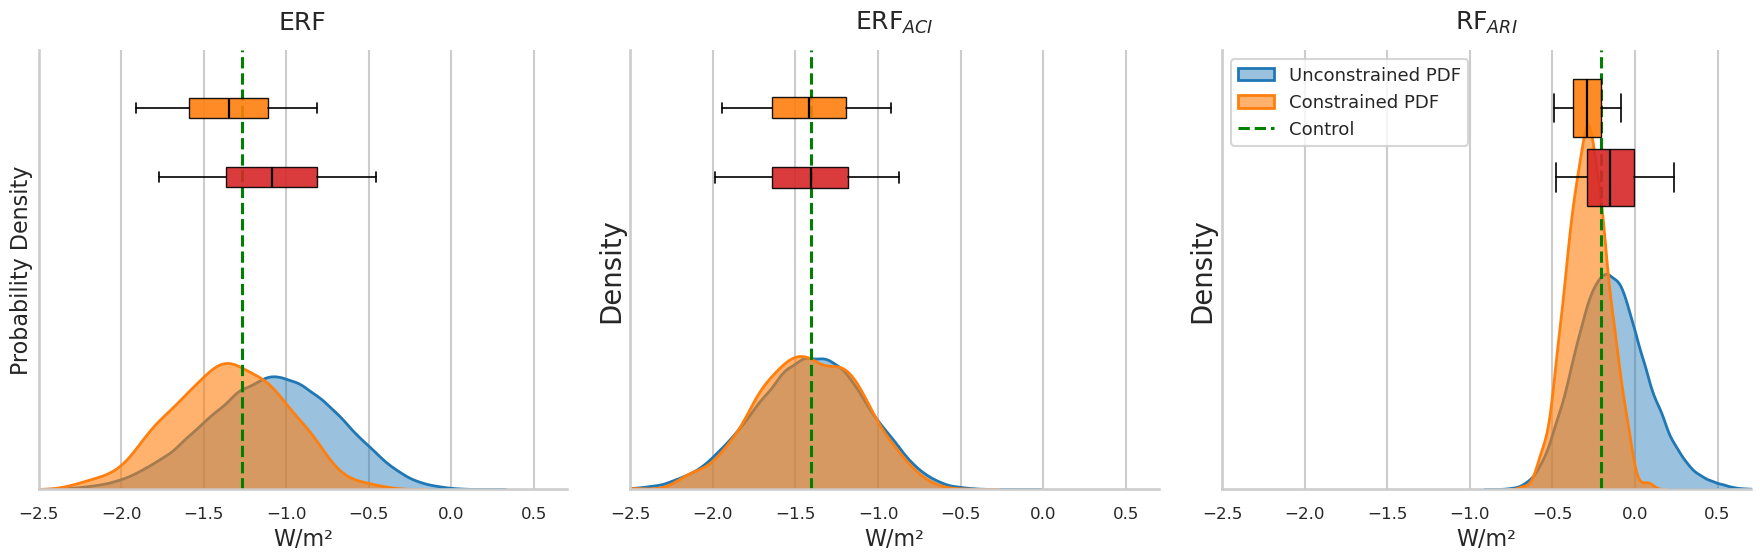

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

accepted_members_best = np.where(accepted_both)[0]
n_samples_new = 100000
# Prepare accepted datasets
Full_ERF = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERF/emulated_erf_{n_samples_new}.nc')['Emulated ERF'].sel(region='Global').mean('month')
Accepted_ERF = Full_ERF.sel(sample=accepted_members_best)

Full_ERFaci = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFaci/emulated_erfaci_{n_samples_new}.nc')['Emulated ERFaci'].sel(region='Global').mean('month')
Accepted_ERFaci = Full_ERFaci.sel(sample=accepted_members_best)

Full_ERFari = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFari/emulated_erfari_{n_samples_new}.nc')['Emulated ERFari'].sel(region='Global').mean('month')
Accepted_ERFari = Full_ERFari.sel(sample=accepted_members_best)


sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

datasets = [
    ("ERF", Full_ERF, Accepted_ERF),
    ("ERF$_{ACI}$", Full_ERFaci, Accepted_ERFaci),
    ("RF$_{ARI}$", Full_ERFari, Accepted_ERFari),
]

colors = {"full": "#1f77b4", "acc": "#ff7f0e"}  # blue/orange for PDFs
box_colors = {"full": "#d62728", "acc": "#ff7f0e"}  # red/orange for boxes

for ax, (title, full, acc) in zip(axes, datasets):

    # --- KDE plots ---
    sns.kdeplot(full, fill=True, ax=ax, color=colors["full"], alpha=0.45, linewidth=2, label="Unconstrained PDF")
    sns.kdeplot(acc, fill=True, ax=ax, color=colors["acc"], alpha=0.6, linewidth=2, label="Constrained PDF")

    # --- Control line ---
    ax.axvline(full[0], color="green", linestyle="--", linewidth=2.2, label="Control")

    # --- Boxplot positions (vertically placed to align with PDFs mid-height) ---
    ymax = ax.get_ylim()[1]
    y_pdf_mid = 0.4 * ymax   # position where the boxplots will sit

    # Function to draw horizontal boxplots aligned with PDF x-axis
    def draw_boxplot(ax, data, y_center, color, label):
        p = np.percentile(data, [5, 25, 50, 75, 95])
        ax.bxp([{
            'med': p[2],
            'q1':  p[1],
            'q3':  p[3],
            'whislo': p[0],
            'whishi': p[4],
            'mean': None,
            'fliers': []
        }], positions=[y_center], widths=0.15*ymax, vert=False,
        patch_artist=True,
        boxprops={'facecolor': color, 'edgecolor': 'black', 'alpha': 0.9},
        medianprops={'color': 'black', 'linewidth': 1.6},
        whiskerprops={'color': 'black', 'linewidth': 1.2},
        capprops={'color': 'black', 'linewidth': 1.2})

    # --- Draw boxplots ---
    draw_boxplot(ax, full, 2.7, box_colors["full"], "Unconstrained")
    draw_boxplot(ax, acc,  3.3, box_colors["acc"],  "Constrained")

    # --- Labels & titles ---
    ax.set_title(title, fontsize=18, pad=15)
    ax.set_xlabel("W/m²", fontsize=16)
    ax.tick_params(axis="x", labelsize=12)
    if ax is axes[0]:
        ax.set_ylabel("Probability Density", fontsize=16)
    ax.set_xlim([-2.5,0.7])
    ax.set_yticks([])  # removes y-axis labels

    # Legend
    if ax is axes[2]:
        ax.legend(frameon=True, fontsize=13, loc="upper left")

sns.despine()
plt.tight_layout()
plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Constrained_ERF.png", dpi=100, bbox_inches='tight')
#plt.savefig("/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Constrained_ERF_Important_Parameters.png", dpi=100, bbox_inches='tight')

plt.show()


# Linear Correlations

/scratch-local/ybhatti2.16851601/ipykernel_3703128/1925885202.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])
/scratch-local/ybhatti2.16851601/ipykernel_3703128/1925885202.py:116: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 0.91, 1])


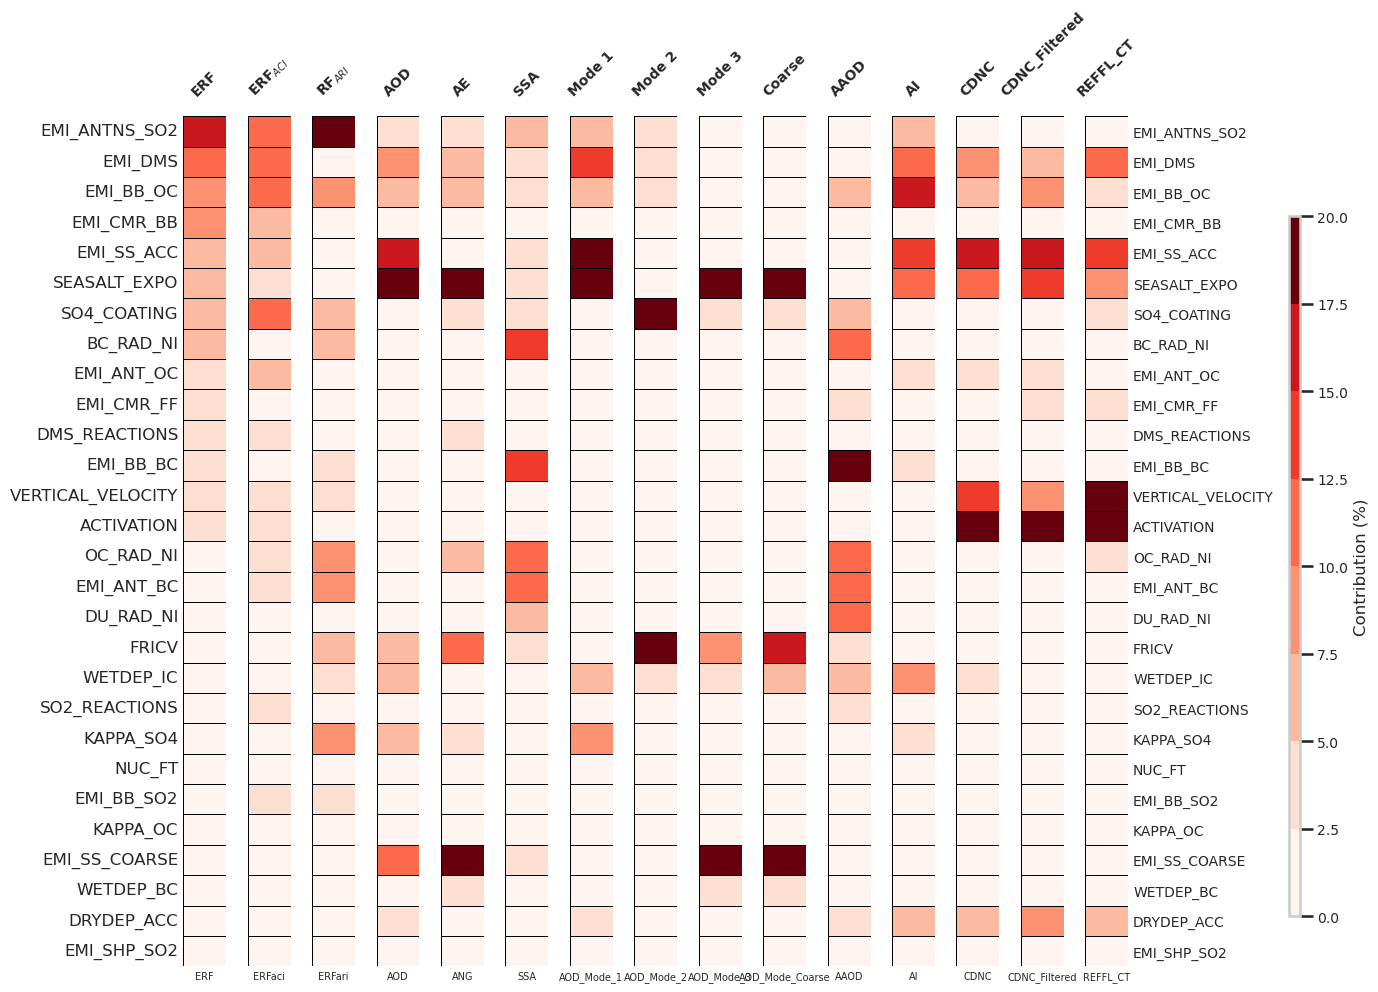

Unique to ERF: ['SCALE_EMI_CMR_FF']
Unique to ERFaci: ['SCALE_SO2_REACTIONS']
Unique to ERFari: ['KAPPA_SO4', 'SCALE_FRICV', 'SCALE_WETDEP_IC']
Shared (others): ['BC_RAD_NI', 'OC_RAD_NI', 'SCALE_ACTIVATION', 'SCALE_DMS_REACTIONS', 'SCALE_EMI_ANTNS_SO2', 'SCALE_EMI_ANT_BC', 'SCALE_EMI_ANT_OC', 'SCALE_EMI_BB_BC', 'SCALE_EMI_BB_OC', 'SCALE_EMI_BB_SO2', 'SCALE_EMI_CMR_BB', 'SCALE_EMI_DMS', 'SCALE_EMI_SS_ACC', 'SCALE_SEASALT_EXPO', 'SCALE_SO4_COATING', 'SCALE_VERTICAL_VELOCITY']
Interesting parameters: ['BC_RAD_NI', 'KAPPA_SO4', 'OC_RAD_NI', 'SCALE_ACTIVATION', 'SCALE_DMS_REACTIONS', 'SCALE_EMI_ANTNS_SO2', 'SCALE_EMI_ANT_BC', 'SCALE_EMI_ANT_OC', 'SCALE_EMI_BB_BC', 'SCALE_EMI_BB_OC', 'SCALE_EMI_BB_SO2', 'SCALE_EMI_CMR_BB', 'SCALE_EMI_CMR_FF', 'SCALE_EMI_DMS', 'SCALE_EMI_SS_ACC', 'SCALE_FRICV', 'SCALE_SEASALT_EXPO', 'SCALE_SO2_REACTIONS', 'SCALE_SO4_COATING', 'SCALE_VERTICAL_VELOCITY', 'SCALE_WETDEP_IC']


In [293]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df_merged from before
Combined_Uncertainty_Contributions = Combined_Uncertainty_Contribution.sort_values(
    by='ERF', ascending=False
)

# Melt to long format for plotting
results_all = Combined_Uncertainty_Contributions.melt(
    id_vars='Variable',
    var_name='Diagnostic',
    value_name='corrcoef'  # using your CSV numbers instead of computed correlation
)

# Clean parameter names
results_all["Parameter"] = results_all["Variable"].str.replace("SCALE_", "", regex=False)

# Optional: define order of parameters
params_order = sorted(results_all["Parameter"].unique())
params_order = results_all[results_all['Diagnostic']=='ERF']\
                .sort_values('corrcoef', ascending=False)['Parameter'].tolist()


diagnostics_order = [
    "ERF", "ERFaci", "ERFari", "AOD", "ANG", "SSA",
    "AOD_Mode_1", "AOD_Mode_2", "AOD_Mode_3", "AOD_Mode_Coarse",
    "AAOD", "AI", "CDNC", "CDNC_Filtered", "REFFL_CT"
]
titles = [
    "ERF", "ERF$_{ACI}$", "RF$_{ARI}$",
    "AOD", "AE", "SSA",
    "Mode 1", "Mode 2", "Mode 3",
    "Coarse", "AAOD", "AI", "CDNC", 
    "CDNC_Filtered", "REFFL_CT"
]

# Plot heatmap
fig, axes = plt.subplots(1, len(diagnostics_order),
                         figsize=(7,10),
                         sharey=True)
plt.subplots_adjust(left=0.05, right=1.4, bottom=0.1, top=0.95, wspace=0.5)

if len(diagnostics_order) == 1:
    axes = [axes]

vlim = results_all['corrcoef'].max()
cmap = 'cividis'
bounds = [0, 5, 10, 15, 20]
cmap = mcolors.ListedColormap(["#fff5f0", "#fcbba1", "#fb6a4a", "#67000d"])  # light to dark red
bounds = np.arange(0, 22.5, 2.5)  # 0, 2.5, 5, ..., 20

# Generate a gradient of reds for each bin
colors = ["#fff5f0", "#fee0d2", "#fcbba1", "#fc9272", "#fb6a4a",
          "#ef3b2c", "#cb181d", "#67000d"]  # light to dark red
cmap = mcolors.LinearSegmentedColormap.from_list("red_gradient", colors, N=len(bounds)-1)

norm = mcolors.BoundaryNorm(bounds, cmap.N)


for ax_i, (ax, diag) in enumerate(zip(axes, diagnostics_order)):
    sub = results_all[results_all["Diagnostic"] == diag]
    mat = sub.set_index('Parameter')['corrcoef'].reindex(params_order).values[:, np.newaxis]

    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        norm=norm,
        cbar=False,
        xticklabels=[diag],
        yticklabels=params_order,
        square=False,
        linewidths=0.5,
        linecolor='black'
    )

    ax.text(
        0.5, 1.025, titles[ax_i],  # x, y in axes fraction coordinates
        transform=ax.transAxes,
        fontsize=10,
        fontweight='bold',
        ha='center',
        rotation=45
    )

  #  ax.set_title(titles[ax_i], fontsize=7, pad=12, weight='bold',rotate=45)
    ax.set_xticklabels([diag], rotation=0, fontsize=7)
    ax.set_yticklabels(params_order, rotation=0, fontsize=12)
    ax.tick_params(axis='both', length=0)
    
    if ax_i == len(axes)-1:
        ax_right = ax.twinx()
        ax_right.set_ylim(ax.get_ylim())
        ax_right.set_yticks(np.arange(0.5, len(params_order)+0.5))
        ax_right.set_yticklabels(params_order, rotation=0, fontsize=10)
        ax_right.tick_params(axis='y', length=0)
        
        # Make spines and frame invisible
        for spine in ax_right.spines.values():
            spine.set_visible(False)
        ax_right.set_frame_on(False)
        
        # Remove horizontal grid lines that may be drawn by Seaborn
        ax_right.grid(False)

# Shared colorbar
cbar_ax = fig.add_axes([1.63, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=20))  # vmax fixed at 20
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Contribution (%)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig(f"/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Heat_Map_Contribution.png",dpi=100,bbox_inches = 'tight')
plt.show()

Combined_Uncertainty_Contribution_filtered_ERF = Combined_Uncertainty_Contribution[
    Combined_Uncertainty_Contribution['ERF'] > 2.5
]
Combined_Uncertainty_Contribution_filtered_ERFaci = Combined_Uncertainty_Contribution[
    Combined_Uncertainty_Contribution['ERFaci'] > 2.5
]
Combined_Uncertainty_Contribution_filtered_ERFari = Combined_Uncertainty_Contribution[
    Combined_Uncertainty_Contribution['ERFari'] > 2.5
]

# Convert to sets
ERF_set    = set(Combined_Uncertainty_Contribution_filtered_ERF['Variable'])
ERFaci_set = set(Combined_Uncertainty_Contribution_filtered_ERFaci['Variable'])
ERFari_set = set(Combined_Uncertainty_Contribution_filtered_ERFari['Variable'])

# Unique to each diagnostic
unique_ERF    = ERF_set - (ERFaci_set | ERFari_set)
unique_ERFaci = ERFaci_set - (ERF_set | ERFari_set)
unique_ERFari = ERFari_set - (ERF_set | ERFaci_set)

# Shared / others (appear in more than one diagnostic)
others = (ERF_set & ERFaci_set) | (ERF_set & ERFari_set) | (ERFaci_set & ERFari_set)

# Display
print("Unique to ERF:", sorted(unique_ERF))
print("Unique to ERFaci:", sorted(unique_ERFaci))
print("Unique to ERFari:", sorted(unique_ERFari))
print("Shared (others):", sorted(others))

# 1. Combine interesting parameters
interesting_params = sorted(ERF_set | ERFaci_set | ERFari_set)
print("Interesting parameters:", interesting_params)


/scratch-local/ybhatti2.16851601/ipykernel_3703128/4190634114.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])
/scratch-local/ybhatti2.16851601/ipykernel_3703128/4190634114.py:125: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 0.91, 1])


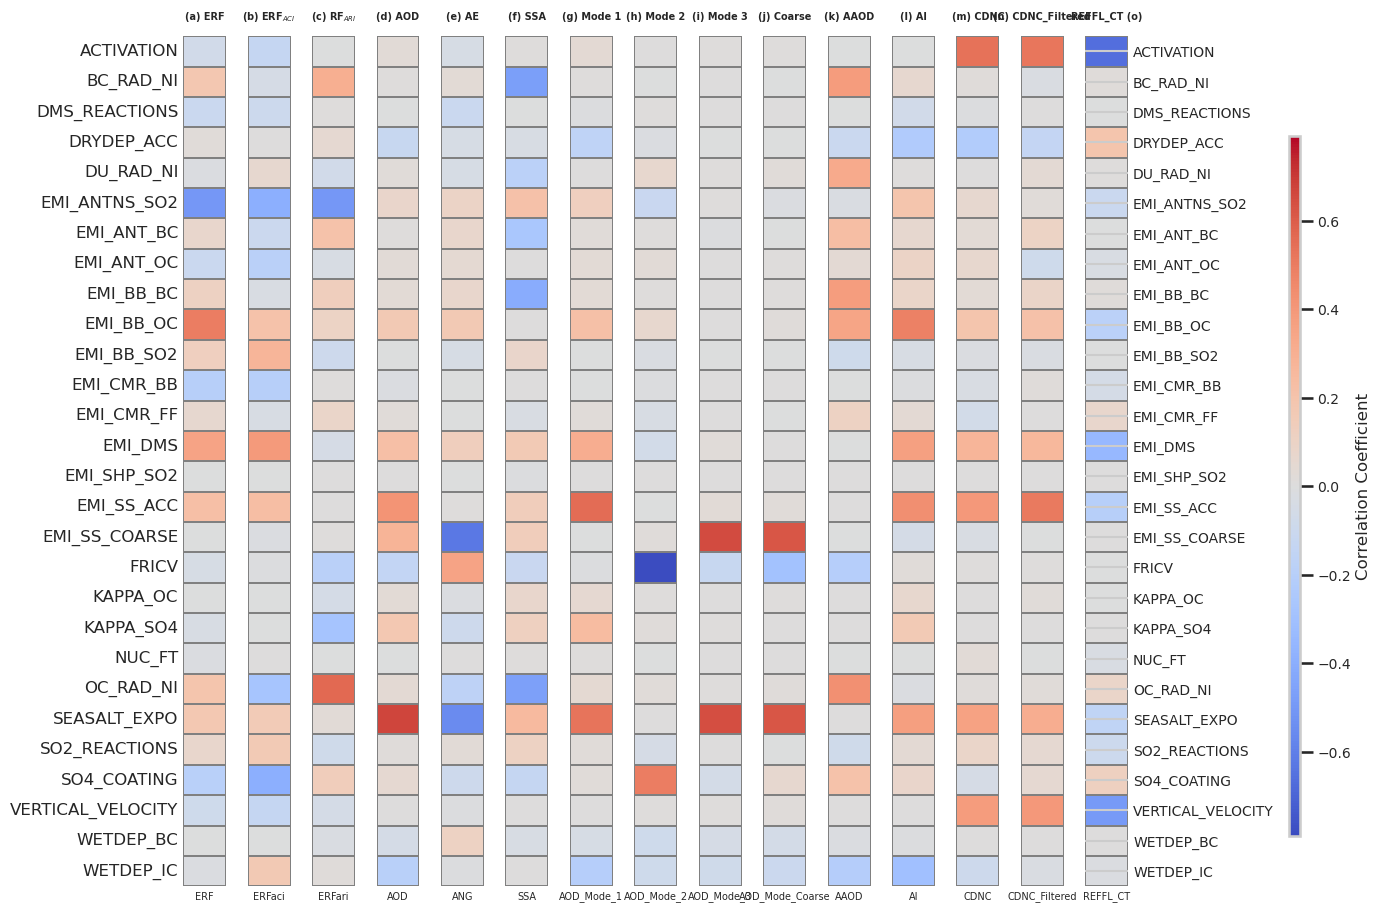

In [103]:
n_samples_new = 100000
n_samples = 100000

Full_ERF = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERF/emulated_erf_{n_samples_new}.nc')['Emulated ERF'].sel(region='Global').mean('month')#[:-1]

Full_ERFaci = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFaci/emulated_erfaci_{n_samples_new}.nc')['Emulated ERFaci'].sel(region='Global').mean('month')#[:-1]

Full_ERFari = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFari/emulated_erfari_{n_samples_new}.nc')['Emulated ERFari'].sel(region='Global').mean('month')#[:-1]


params = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_non_norm_{n_samples_new}.csv')
params = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples_new}.csv')
params.set_index(params.columns[0], inplace=True)

# --- Compute correlations per parameter ---
corr_ERF    = params.apply(lambda col: np.corrcoef(col.values, Full_ERF)[0,1])
corr_ERFaci = params.apply(lambda col: np.corrcoef(col.values, Full_ERFaci)[0,1])
corr_ERFari = params.apply(lambda col: np.corrcoef(col.values, Full_ERFari)[0,1])
corr_aod = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD'].sel(region='Global')[:-1])[0,1])
corr_ang = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['ANG'].sel(region='Global')[:-1])[0,1])
corr_ssa = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['SSA'].sel(region='Global')[:-1])[0,1])
corr_aod_mode_1 = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_1'].sel(region='Global')[:-1])[0,1])
corr_aod_mode_2 = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_2'].sel(region='Global')[:-1])[0,1])
corr_aod_mode_3 = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_3'].sel(region='Global')[:-1])[0,1])
corr_aod_mode_coarse = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_Coarse'].sel(region='Global')[:-1])[0,1])
corr_aod_mode_aaod = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AAOD'].sel(region='Global')[:-1])[0,1])
corr_ai = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AI'].sel(region='Global')[:-1])[0,1])
corr_cdnc = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['CDNC'].sel(region='Global')[:-1])[0,1])
corr_cdnc_filtered = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['CDNC_Filtered'].sel(region=region)[:-1])[0,1])
corr_reffl_ct = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['REFFL_CT'].sel(region=region)[:-1])[0,1])

results_all = pd.DataFrame({
    'Parameter': params.columns,
    'ERF': corr_ERF.values,
    'ERFaci': corr_ERFaci.values,
    'ERFari': corr_ERFari.values,
    'AOD': corr_aod.values,
    'ANG': corr_ang.values,
    'SSA': corr_ssa.values,
    'AOD_Mode_1': corr_aod_mode_1.values,
    'AOD_Mode_2': corr_aod_mode_2.values,
    'AOD_Mode_3': corr_aod_mode_3.values,
    'AOD_Mode_Coarse': corr_aod_mode_coarse.values,
    'AAOD': corr_aod_mode_aaod.values,
    'AI': corr_ai.values,
    'CDNC': corr_cdnc.values,
    'CDNC_Filtered': corr_cdnc_filtered.values,
    'REFFL_CT': corr_reffl_ct.values

}).melt(id_vars='Parameter', var_name='Diagnostic', value_name='corrcoef')


# --- Clean parameter names ---
results_all["Parameter"] = results_all["Parameter"].str.replace("SCALE_", "", regex=False)

# --- Optional: define order of parameters (or just sort alphabetically) ---
params_order = sorted(results_all["Parameter"].unique())
diagnostics_order = [
    "ERF", "ERFaci", "ERFari", "AOD", "ANG", "SSA",
    "AOD_Mode_1", "AOD_Mode_2", "AOD_Mode_3", "AOD_Mode_Coarse",
    "AAOD", "AI", "CDNC", "CDNC_Filtered", "REFFL_CT"
]
titles = [
    "(a) ERF", "(b) ERF$_{ACI}$", "(c) RF$_{ARI}$",
    "(d) AOD", "(e) AE", "(f) SSA",
    "(g) Mode 1", "(h) Mode 2", "(i) Mode 3",
    "(j) Coarse", "(k) AAOD", "(l) AI", "(m) CDNC", 
    "(n) CDNC_Filtered", "REFFL_CT (o)"
]

# --- Plot heatmap ---
fig, axes = plt.subplots(1, len(diagnostics_order),
                         figsize=(7,10) ,
                         sharey=True)
plt.subplots_adjust(left=0.05, right=1.4, bottom=0.1, top=0.95, wspace=0.5)  # increase wspace

if len(diagnostics_order) == 1:
    axes = [axes]

vlim = np.nanmax(np.abs(results_all['corrcoef']))

for ax_i, (ax, diag) in enumerate(zip(axes, diagnostics_order)):
    sub = results_all[results_all["Diagnostic"] == diag]
    mat = sub.set_index('Parameter')['corrcoef'].reindex(params_order).values[:, np.newaxis]  # single column heatmap

    sns.heatmap(
        mat,
        ax=ax,
        cmap="coolwarm",
        center=0,
        vmin=-vlim,
        vmax=vlim,
        cbar=False,
        xticklabels=[diag],
        yticklabels=params_order,
        square=False,
        linewidths=0.2,
        linecolor='grey'
    )

    ax.set_title(titles[ax_i], fontsize=7, pad=12, weight='bold')
    ax.set_xticklabels([diag], rotation=0, fontsize=7)
    ax.set_yticklabels(params_order, rotation=0, fontsize=12)
    ax.tick_params(axis='both', length=0)
    # --- Add right-side labels on the last subplot ---
    if ax_i == len(axes)-1:
        ax_right = ax.twinx()
        ax_right.set_ylim(ax.get_ylim())
        ax_right.set_yticks(np.arange(0.5, len(params_order)+0.5))
        ax_right.set_yticklabels(params_order, rotation=0, fontsize=10)
        ax_right.tick_params(axis='y', length=0)
        for spine in ax_right.spines.values():
            spine.set_visible(False)
        ax_right.set_frame_on(False)

# --- Shared colorbar ---
# --- Shared colorbar ---
cbar_ax = fig.add_axes([1.63, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=-vlim, vmax=vlim))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Correlation Coefficient", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig(f"/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Heat_Map.png",dpi=100,bbox_inches = 'tight')
plt.show()


In [22]:
params = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_non_norm_{n_samples_new}.csv')
params = pd.read_csv(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/ppe_params_{n_samples_new}.csv')
params.set_index(params.columns[0], inplace=True)

for region in region_names:

    corr_ERF    = params.apply(lambda col: np.corrcoef(col.values, Full_ERF)[0,1])
    corr_ERFaci = params.apply(lambda col: np.corrcoef(col.values, Full_ERFaci)[0,1])
    corr_ERFari = params.apply(lambda col: np.corrcoef(col.values, Full_ERFari)[0,1])

    corr_aod = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD'].sel(region=region)[:-1])[0,1])
    corr_ang = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['ANG'].sel(region=region)[:-1])[0,1])
    corr_ssa = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['SSA'].sel(region=region)[:-1])[0,1])

    corr_aod_mode_1 = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_1'].sel(region=region)[:-1])[0,1])
    corr_aod_mode_2 = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_2'].sel(region=region)[:-1])[0,1])
    corr_aod_mode_3 = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_3'].sel(region=region)[:-1])[0,1])
    corr_aod_mode_coarse = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AOD_Mode_Coarse'].sel(region=region)[:-1])[0,1])
    corr_aod_mode_aaod = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AAOD'].sel(region=region)[:-1])[0,1])
    corr_ai = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['AI'].sel(region=region)[:-1])[0,1])
    corr_cdnc = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['CDNC'].sel(region=region)[:-1])[0,1])
    corr_cdnc_filtered = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['CDNC_Filtered'].sel(region=region)[:-1])[0,1])
    corr_reffl_ct = params.apply(lambda col: np.corrcoef(col.values, boxplot_dataset['REFFL_CT'].sel(region=region)[:-1])[0,1])

    results_all = pd.DataFrame({
        'Parameter': params.columns,
        'ERF': corr_ERF.values,
        'ERFaci': corr_ERFaci.values,
        'ERFari': corr_ERFari.values,
        'AOD': corr_aod.values,
        'ANG': corr_ang.values,
        'SSA': corr_ssa.values,
        'AOD_Mode_1': corr_aod_mode_1.values,
        'AOD_Mode_2': corr_aod_mode_2.values,
        'AOD_Mode_3': corr_aod_mode_3.values,
        'AOD_Mode_Coarse': corr_aod_mode_coarse.values,
        'AAOD': corr_aod_mode_aaod.values,
        'AI': corr_ai.values,
        'CDNC': corr_cdnc.values,
        'CDNC_Filtered': corr_cdnc_filtered.values,
        'REFFL_CT': corr_reffl_ct.values

    }).melt(id_vars='Parameter', var_name='Diagnostic', value_name='corrcoef')

    results_all["Parameter"] = results_all["Parameter"].str.replace("SCALE_", "", regex=False)

    # plotting block remains unchanged — except filename:
    # plt.savefig(
    #     f"/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Heat_Map_{region}.png",
    #     dpi=100,
    #     bbox_inches='tight'
    # )
    params_order = sorted(results_all["Parameter"].unique())
    diagnostics_order = [
        "ERF", "ERFaci", "ERFari", "AOD", "ANG", "SSA",
        "AOD_Mode_1", "AOD_Mode_2", "AOD_Mode_3", "AOD_Mode_Coarse",
        "AAOD", "AI", "CDNC", "CDNC_Filtered", "REFFL_CT"
    ]
    titles = [
        "(a) ERF", "(b) ERF$_{ACI}$", "(c) RF$_{ARI}$",
        "(d) AOD", "(e) AE", "(f) SSA",
        "(g) Mode 1", "(h) Mode 2", "(i) Mode 3",
        "(j) Coarse", "(k) AAOD", "(l) AI", "(m) CDNC", 
        "(n) CDNC_Filtered", "REFFL_CT (o)"
    ]

    # --- Plotting ---
    fig, axes = plt.subplots(1, len(diagnostics_order),
                             figsize=(7,10),
                             sharey=True)
    plt.subplots_adjust(left=0.05, right=1.4, bottom=0.1, top=0.95, wspace=0.5)

    vlim = np.nanmax(np.abs(results_all['corrcoef']))

    for ax_i, (ax, diag) in enumerate(zip(axes, diagnostics_order)):
        sub = results_all[results_all["Diagnostic"] == diag]
        mat = sub.set_index('Parameter')['corrcoef'].reindex(params_order).values[:, np.newaxis]

        sns.heatmap(
            mat,
            ax=ax,
            cmap="coolwarm",
            center=0,
            vmin=-vlim,
            vmax=vlim,
            cbar=False,
            xticklabels=[diag],
            yticklabels=params_order,
            square=False,
            linewidths=0.2,
            linecolor='grey'
        )

        ax.set_title(titles[ax_i], fontsize=7, pad=12, weight='bold')
        ax.set_xticklabels([diag], rotation=0, fontsize=7)
        ax.set_yticklabels(params_order, rotation=0, fontsize=12)
        ax.tick_params(axis='both', length=0)

        if ax_i == len(axes)-1:
            ax_right = ax.twinx()
            ax_right.set_ylim(ax.get_ylim())
            ax_right.set_yticks(np.arange(0.5, len(params_order)+0.5))
            ax_right.set_yticklabels(params_order, rotation=0, fontsize=10)
            ax_right.tick_params(axis='y', length=0)
            for spine in ax_right.spines.values():
                spine.set_visible(False)
            ax_right.set_frame_on(False)

    # Colorbar
    cbar_ax = fig.add_axes([1.63, 0.15, 0.015, 0.7])
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=-vlim, vmax=vlim))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Correlation Coefficient", fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    plt.title(region, fontsize=15)
    # Save figure for this region
    plt.tight_layout(rect=[0, 0, 0.91, 1])
    plt.show()
    plt.close()


NameError: name 'params' is not defined

# Extreme constraints


In [44]:


# We need to stack region and month so that each ensemble member * 216.

# --- AOD: compute threshold per grid cell (max of 0.02 or 10%) ---

threshold_AOD = xr.ufuncs.maximum(0.025, 0.1 * obs_AOD)  # element-wise max
threshold_AAOD = xr.ufuncs.maximum(0.0032, 0.1 * obs_AAOD)  # element-wise max
threshold_AOD_mode_1 = xr.ufuncs.maximum(0.018, 0.10 * obs_AOD_mode_1)  # element-wise max
threshold_AOD_mode_2 = xr.ufuncs.maximum(0.0164, 0.05 * obs_AOD_mode_2)  # element-wise max
threshold_AOD_mode_3 = xr.ufuncs.maximum(0.0062, 0.05 * obs_AOD_mode_3)  # element-wise max
threshold_AI = xr.ufuncs.maximum(0.019, 0.1 * obs_AI)  # element-wise max
threshold_AOD_mode_Coarse = xr.ufuncs.maximum(0.013, 0.05 * obs_AOD_mode_Coarse)  # element-wise max
threshold_CDNC = (0.19 * obs_CDNC) 
threshold_CDNC_Filtered = (0.6 * obs_CDNC_Filtered) 
threshold_REFFL_CT = (0.177 * obs_REFFL_CT) 

fraction_per_sample_aod = (Abs_Diff_AOD < threshold_AOD).mean(dim="z")
fraction_per_sample_ang = (Abs_Diff_ANG < 0.13).mean(dim="z")
fraction_per_sample_aaod = (Abs_Diff_AAOD < threshold_AAOD).mean(dim="z")
fraction_per_sample_ssa = (Abs_Diff_SSA < 0.023).mean(dim="z")
fraction_per_sample_aod_mode_1 = (Abs_Diff_AOD_Mode_1 < threshold_AOD_mode_1).mean(dim="z")
fraction_per_sample_aod_mode_2 = (Abs_Diff_AOD_Mode_2 < threshold_AOD_mode_2).mean(dim="z")
fraction_per_sample_aod_mode_3 = (Abs_Diff_AOD_Mode_3 < threshold_AOD_mode_3).mean(dim="z")
fraction_per_sample_ai = (Abs_Diff_AI < threshold_AI).mean(dim="z")
fraction_per_sample_aod_mode_coarse = (Abs_Diff_AOD_Mode_Coarse < threshold_AOD_mode_Coarse).mean(dim="z")
fraction_per_sample_cdnc = (Abs_Diff_CDNC < threshold_CDNC).mean(dim="z")
#fraction_per_sample_ang = (Abs_Diff_ANG < 0.2).mean(dim="z")
fraction_per_sample_cdnc_filtered = (Abs_Diff_CDNC_Filtered < threshold_CDNC_Filtered).mean(dim="z")
fraction_per_sample_reffl_ct = (Abs_Diff_REFFL_CT < threshold_REFFL_CT).mean(dim="z")

# test = xr.concat(fraction_per_sample_ang,fraction_per_sample_aod)
# test = xr.concat(test,fraction_per_sample_ssa)

# accepted_overall = test > 0.67

# --- Identify accepted samples (where > 67% of z-points are within threshold) ---
accepted_aod = fraction_per_sample_aod > 0.67
accepted_ang = fraction_per_sample_ang > 0.67
accepted_ssa= fraction_per_sample_ssa> 0.67
accepted_aaod= fraction_per_sample_aaod> 0.67
accepted_aod_mode_1= fraction_per_sample_aod_mode_1> 0.67
accepted_aod_mode_2= fraction_per_sample_aod_mode_2> 0.67
accepted_aod_mode_3= fraction_per_sample_aod_mode_3> 0.67
accepted_ai = fraction_per_sample_ai > 0.67
accepted_aod_mode_coarse = fraction_per_sample_aod_mode_coarse> 0.67
accepted_cdnc = fraction_per_sample_cdnc > 0.67
accepted_cdnc_filtered = fraction_per_sample_cdnc_filtered > 0.67
accepted_reffl_ct = fraction_per_sample_reffl_ct > 0.67

# --- Combine: only accept samples passing both AOD and ANG constraints ---
accepted_both = accepted_aod & accepted_ang & accepted_ssa
accepted_both = accepted_aod & accepted_ang & accepted_aaod

accepted_both = accepted_aod_mode_1 & accepted_aod_mode_2 &accepted_aod_mode_3 & accepted_aod & accepted_ang & accepted_ssa & accepted_aaod
accepted_both = accepted_aod_mode_1 & accepted_ai & accepted_ssa

# --- Compute final percentage ---
accepted_pct = 100 * accepted_both.sum().item() / accepted_both.size
#accepted_pct_overall = 100 * accepted_overall.sum().item() / accepted_overall.size

print(f"Accepted AOD-only = {(accepted_aod.sum().item() / accepted_aod.size) * 100:.2f}%")
print(f"Accepted ANG-only = {(accepted_ang.sum().item() / accepted_ang.size) * 100:.2f}%")
print(f"Accepted SSA-only = {(accepted_ssa.sum().item() / accepted_ssa.size) * 100:.2f}%")
print(f"Accepted AAOD-only = {(accepted_aaod.sum().item() / accepted_aaod.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_1-only = {(accepted_aod_mode_1.sum().item() / accepted_aod_mode_1.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_2-only = {(accepted_aod_mode_2.sum().item() / accepted_aod_mode_2.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_3-only = {(accepted_aod_mode_3.sum().item() / accepted_aod_mode_3.size) * 100:.2f}%")
print(f"Accepted AI-only = {(accepted_ai.sum().item() / accepted_ai.size) * 100:.2f}%")
print(f"Accepted AOD_MODE_coarse-only = {(accepted_aod_mode_coarse.sum().item() / accepted_aod_mode_coarse.size) * 100:.2f}%")
print(f"Accepted CDNC-only = {(accepted_cdnc.sum().item() / accepted_cdnc.size) * 100:.2f}%")
print(f"Accepted CDNC_Filtered-only = {(accepted_cdnc_filtered.sum().item() / accepted_cdnc_filtered.size) * 100:.2f}%")
print(f"Accepted reffl_ct-only = {(accepted_reffl_ct.sum().item() / accepted_reffl_ct.size) * 100:.2f}%")

print(f"Accepted BOTH = {accepted_pct:.3f}%")
#print(f"Accepted aod+ang togehter = {(accepted_overall.sum().item() / accepted_overall.size) * 100:.2f}%")
print(f"TOTAL Number Accepted = {accepted_both.sum().item()} / {accepted_both.size}")


Accepted AOD-only = 3.56%
Accepted ANG-only = 3.45%
Accepted SSA-only = 2.24%
Accepted AAOD-only = 5.60%
Accepted AOD_MODE_1-only = 2.92%
Accepted AOD_MODE_2-only = 3.12%
Accepted AOD_MODE_3-only = 5.08%
Accepted AI-only = 2.79%
Accepted AOD_MODE_coarse-only = 2.42%
Accepted CDNC-only = 5.13%
Accepted CDNC_Filtered-only = 3.00%
Accepted reffl_ct-only = 3.76%
Accepted BOTH = 0.008%
TOTAL Number Accepted = 8 / 100001


Plotting CDNC_Filtered: <xarray.DataArray 'CDNC_Filtered' ()> Size: 8B
array(3004) accepted members


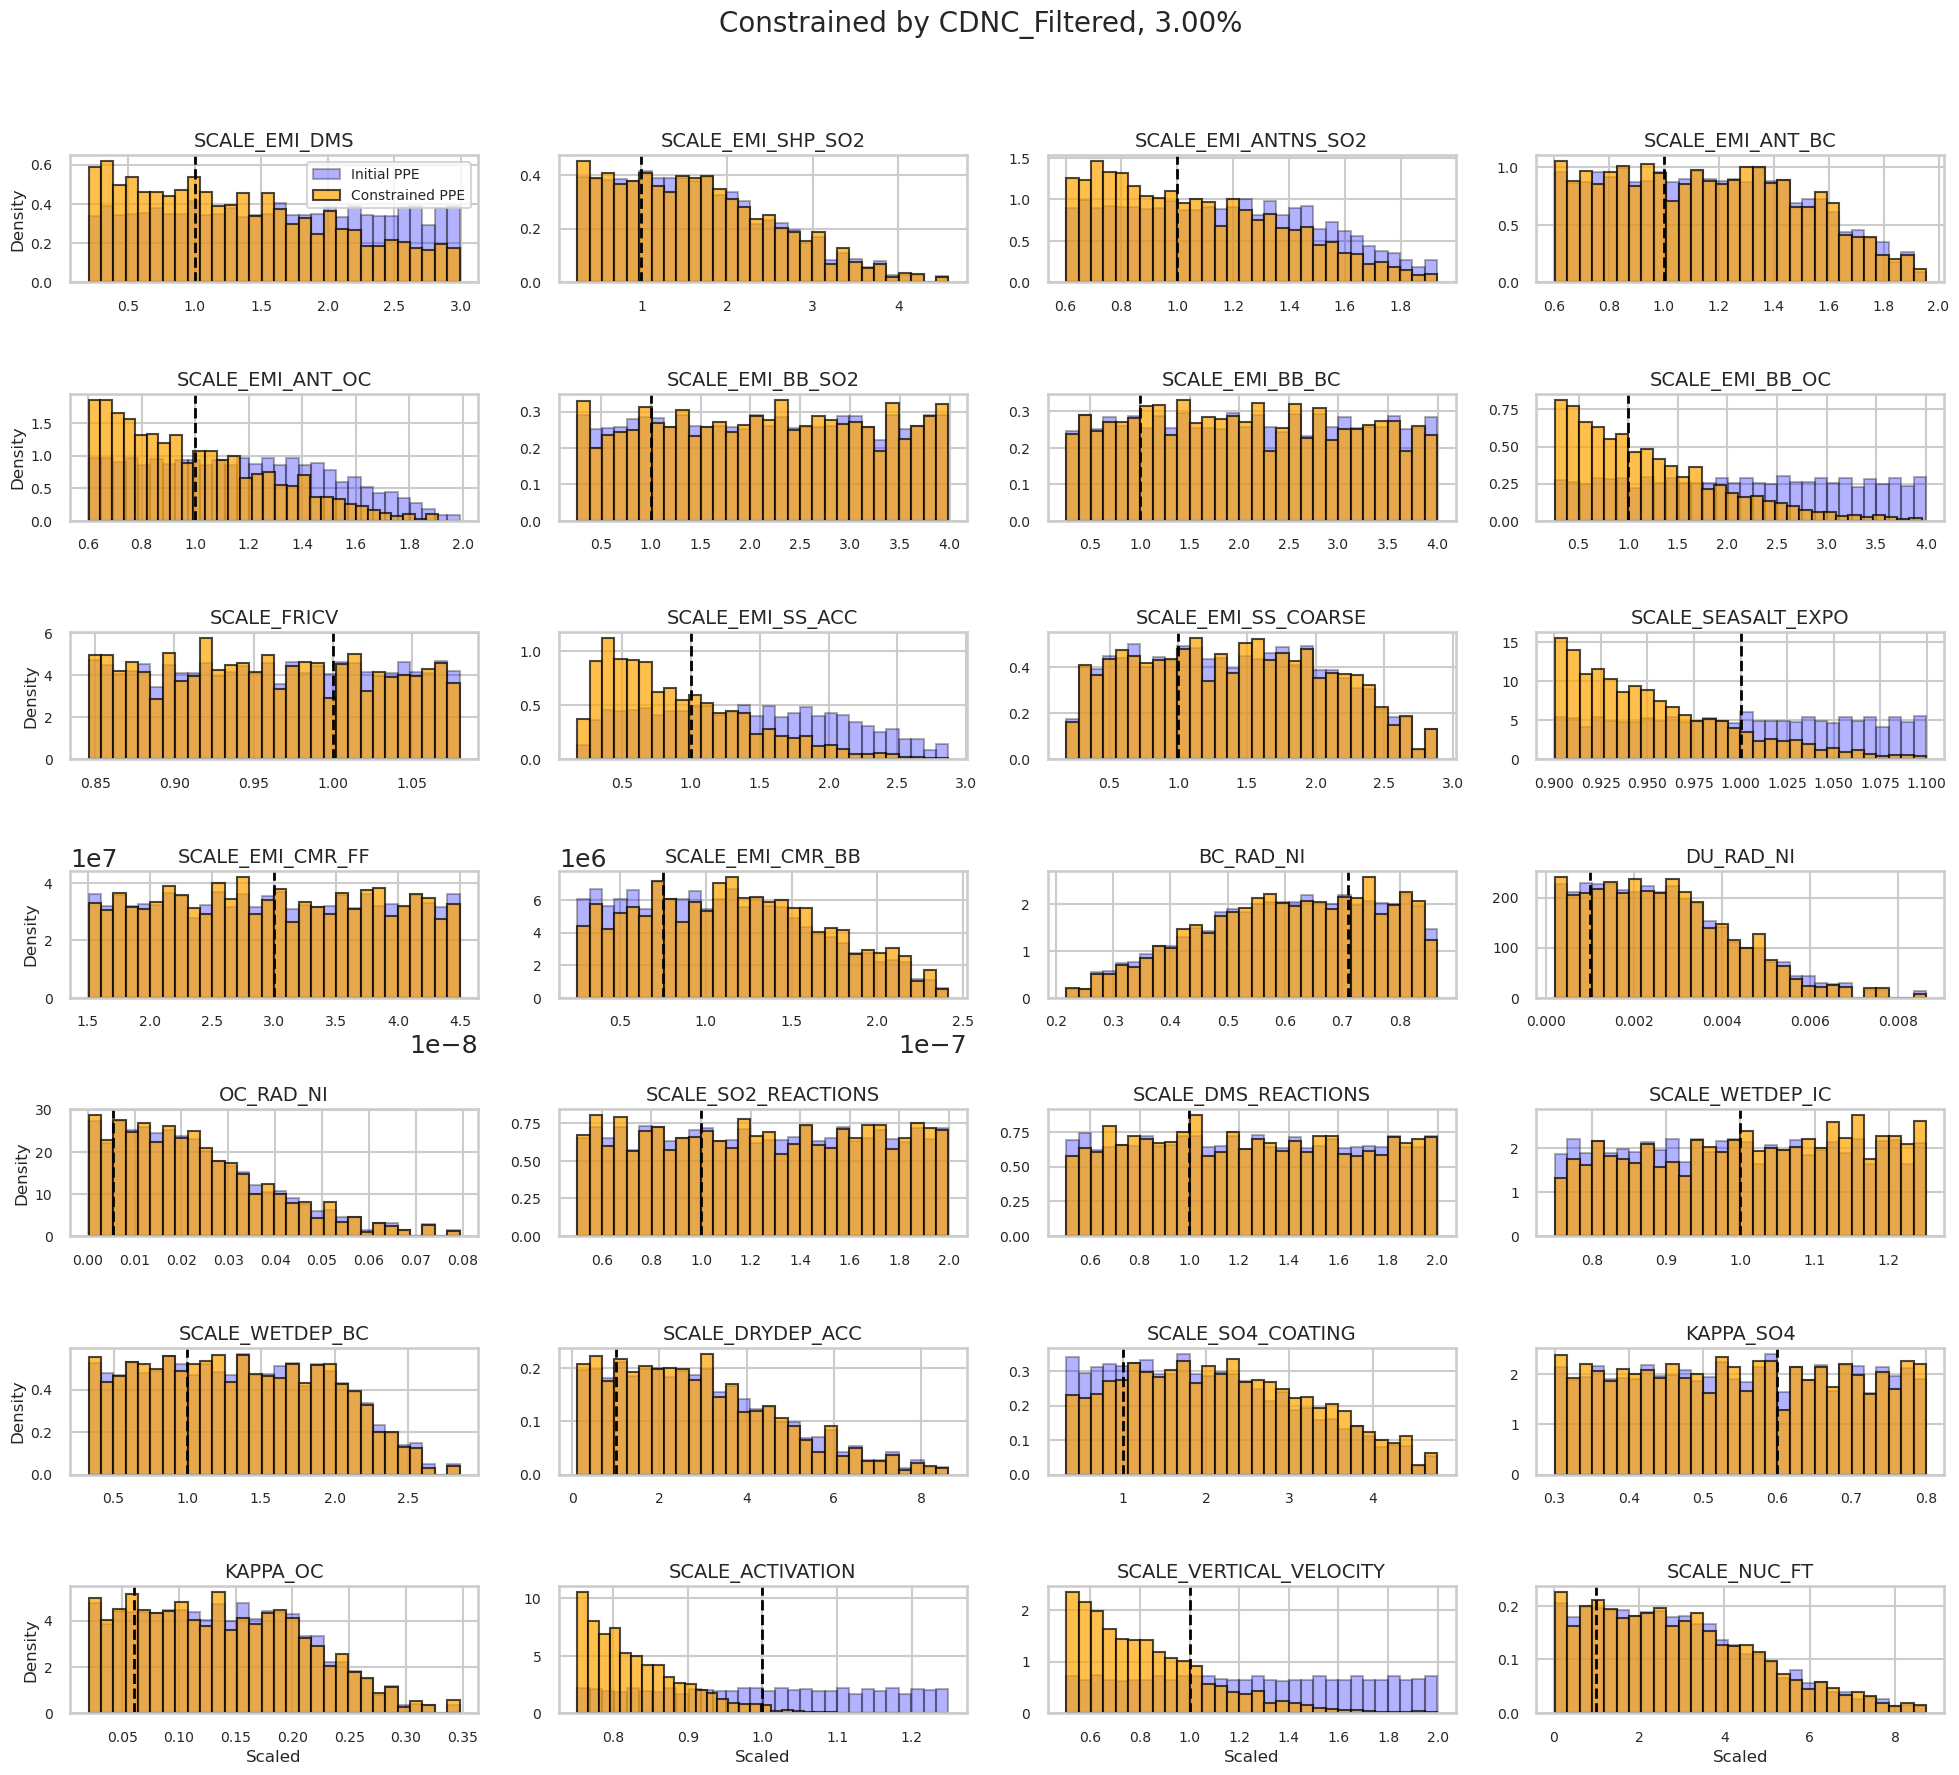

Plotting REFFL_CT: <xarray.DataArray 'REFFL_CT' ()> Size: 8B
array(3760) accepted members


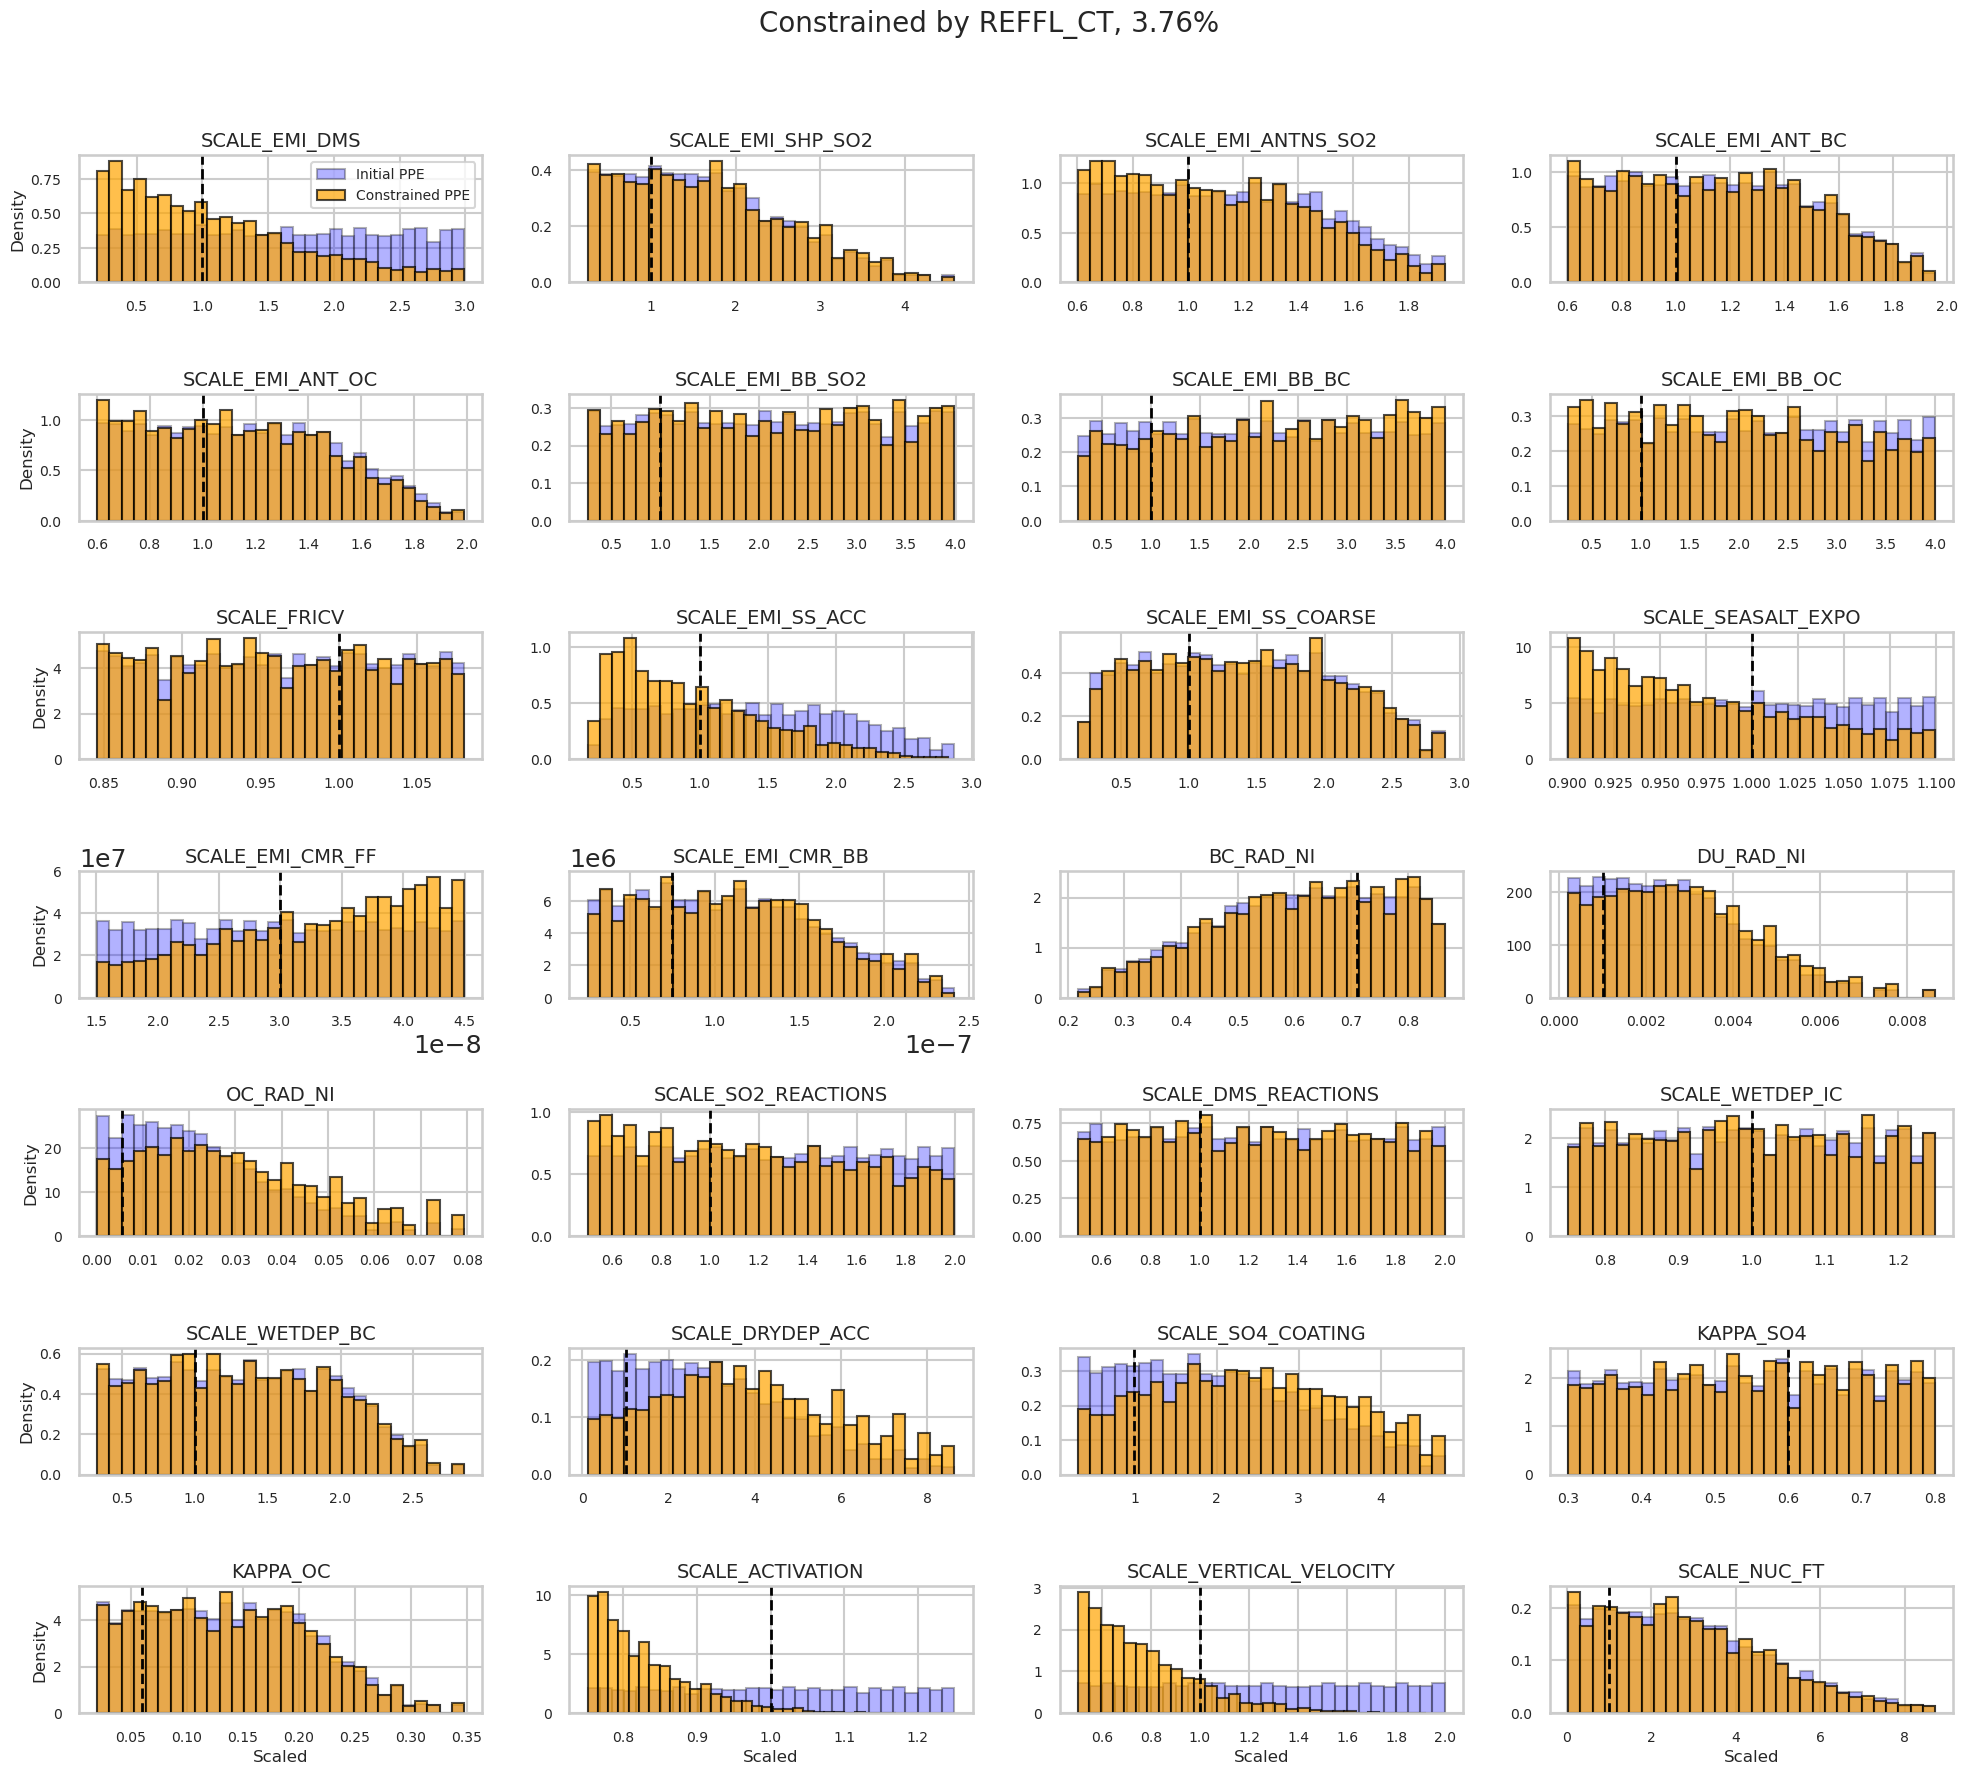

In [42]:
accepted_masks = {
    "AOD": accepted_aod,
    "ANG": accepted_ang,
    "SSA": accepted_ssa,
    "AAOD": accepted_aaod,
    "AOD_mode_1": accepted_aod_mode_1,
    "AOD_mode_2": accepted_aod_mode_2,
    "AOD_mode_3": accepted_aod_mode_3,
    "AI": accepted_ai,
    "AOD_coarse": accepted_aod_mode_coarse,
    "CDNC": accepted_cdnc,
    "CDNC_Filtered": accepted_cdnc_filtered,
    "REFFL_CT": accepted_reffl_ct,

}
accepted_masks = {
    "CDNC_Filtered": accepted_cdnc_filtered,
    "REFFL_CT": accepted_reffl_ct,

}

for name, mask in accepted_masks.items():

    print(f"Plotting {name}: {mask.sum()} accepted members")

    accepted_members_best = np.where(mask)[0]

    shared_dataset_Southern_Ocean = ppe_non_normalized_new_samples.iloc[accepted_members_best]
    control_values = ppe_non_normalized_new_samples.iloc[0]

    num_cols = len(shared_dataset_Southern_Ocean.columns)
    cols_per_row = 4
    rows = num_cols // cols_per_row + int(num_cols % cols_per_row > 0)

    # ---- FIRST PASS: get ymax ----
    ymax = 0
    for col in shared_dataset_Southern_Ocean.columns:
        n_full, _, _ = plt.hist(ppe_non_normalized_new_samples[col], bins=30, density=True)
        n_shared, _, _ = plt.hist(shared_dataset_Southern_Ocean[col], bins=30, density=True)
        ymax = max(ymax, n_full.max(), n_shared.max())
    plt.close()

    # ---- SECOND PASS: plotting ----
    fig, axes = plt.subplots(nrows=rows, ncols=cols_per_row, figsize=(20, rows * 2.5))
    axes = axes.flatten()

    for i, col in enumerate(shared_dataset_Southern_Ocean.columns):
        ax = axes[i]

        # Full ensemble
        ppe_non_normalized_new_samples[col].hist(
            ax=ax, bins=30, edgecolor='black',
            color='blue', alpha=0.3, density=True, label='Initial PPE'
        )

        # Accepted ensemble
        shared_dataset_Southern_Ocean[col].hist(
            ax=ax, bins=30, edgecolor='black',
            color='orange', alpha=0.7, density=True, label='Constrained PPE'
        )

        # Control
        ax.axvline(control_values[col], color="black", linestyle="--", linewidth=2)

        ax.set_title(col, fontsize=14)

        if i % cols_per_row == 0:
            ax.set_ylabel('Density', fontsize=12)
        else:
            ax.set_ylabel('')

        if i < (rows - 1) * cols_per_row:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Scaled', fontsize=12)

        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        if i == 0:
            ax.legend(fontsize=10)

    # Remove leftover empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    #plt.suptitle(f"Constrained by {name}", fontsize=18)
    plt.suptitle(f"Constrained by {name}, {(mask.sum().item() / mask.size) * 100:.2f}%", fontsize=20, y=1.02)

    plt.tight_layout()
    plt.savefig(f"/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Strong_{name}_ERF_pdf_distributions.png",dpi=100,bbox_inches = 'tight')
    plt.show()


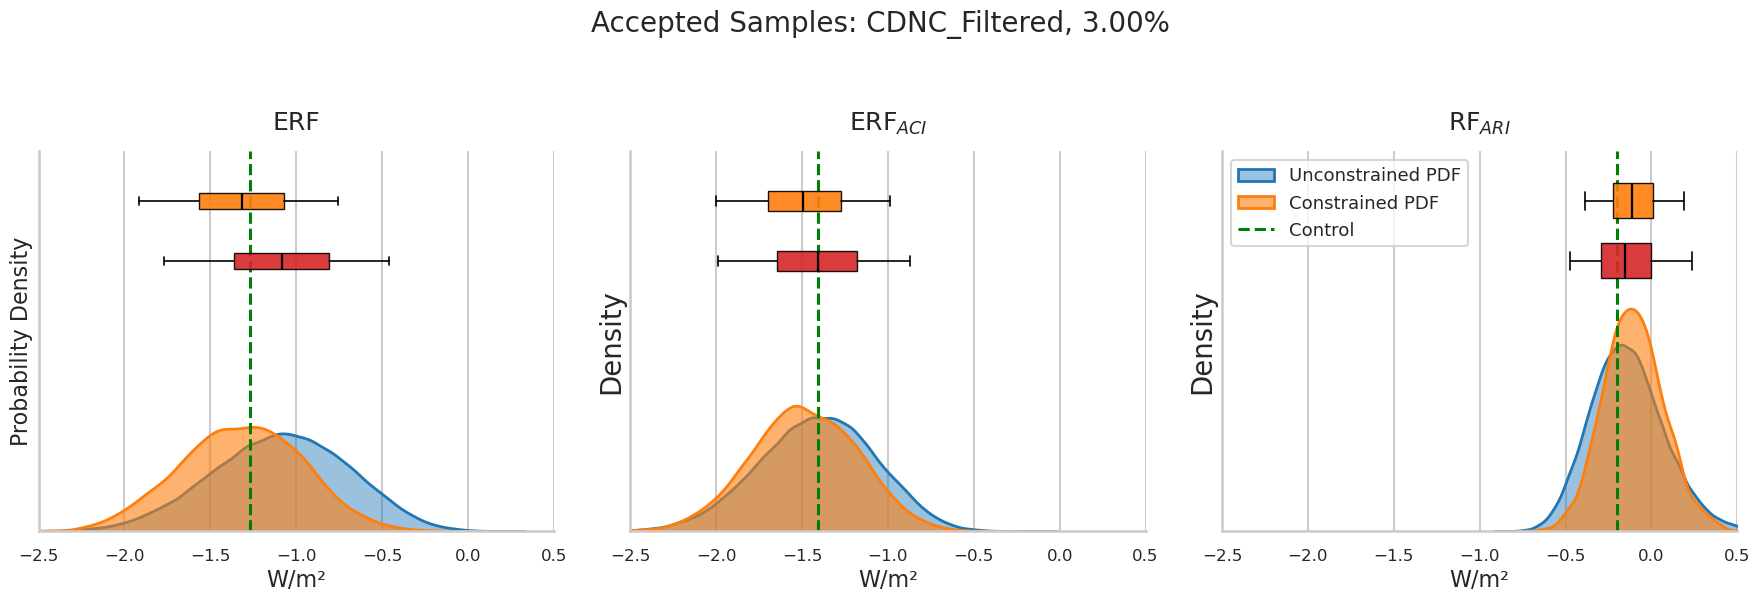

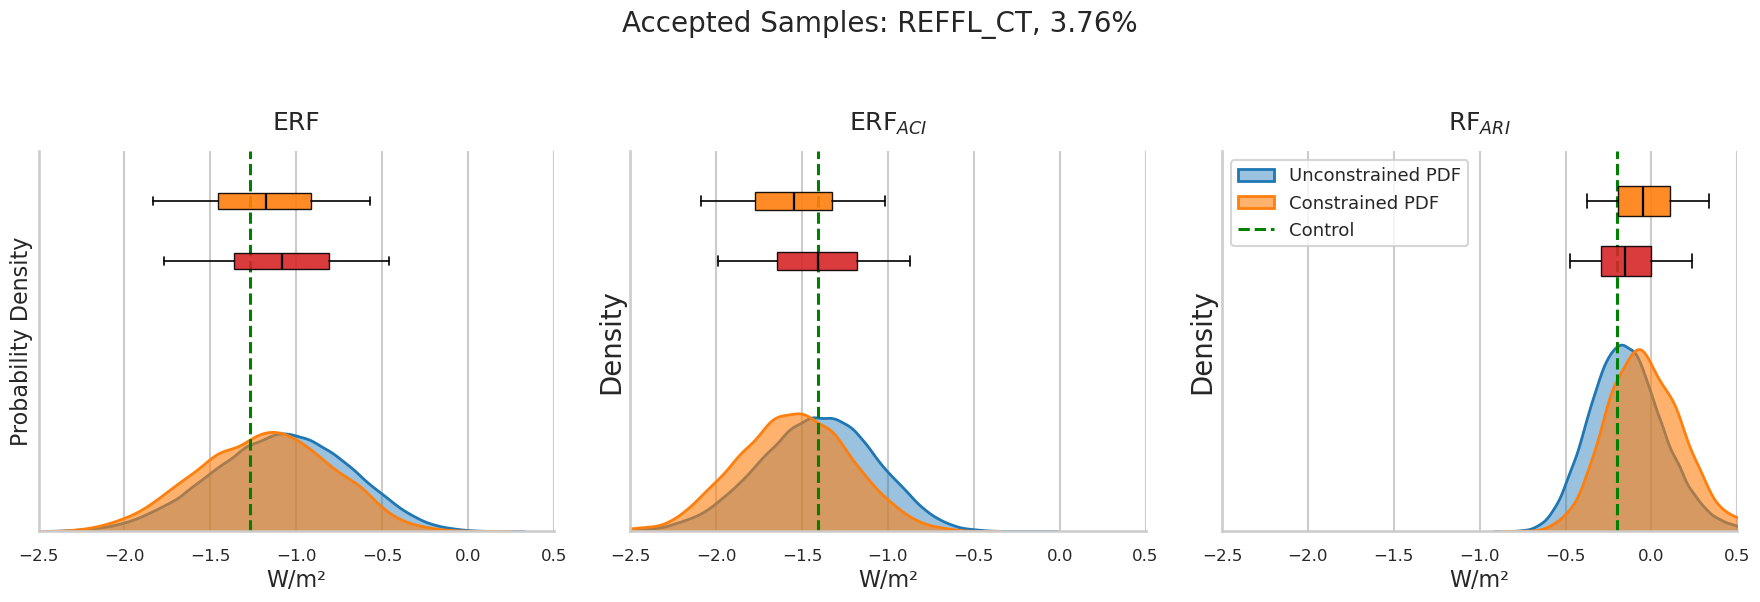

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.1)


# --- List of diagnostics and corresponding accepted masks ---
accepted_list = {
    "AOD": fraction_per_sample_aod > 0.67,
    "ANG": fraction_per_sample_ang > 0.67,
    "SSA": fraction_per_sample_ssa > 0.67,
    "AAOD": fraction_per_sample_aaod > 0.67,
    "AOD_Mode_1": fraction_per_sample_aod_mode_1 > 0.67,
    "AOD_Mode_2": fraction_per_sample_aod_mode_2 > 0.67,
    "AOD_Mode_3": fraction_per_sample_aod_mode_3 > 0.67,
    "AI": fraction_per_sample_ai > 0.67,
    "AOD_Mode_Coarse": fraction_per_sample_aod_mode_coarse > 0.67,
    "CDNC": fraction_per_sample_cdnc > 0.67,
    "CDNC_Filtered": accepted_cdnc_filtered,
    "REFFL_CT": accepted_reffl_ct,

}

accepted_list = {
    "CDNC_Filtered": accepted_cdnc_filtered,
    "REFFL_CT": accepted_reffl_ct,

}

# --- Load full datasets ---
n_samples_new = 100000
# Prepare accepted datasets
Full_ERF = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERF/emulated_erf_{n_samples_new}.nc')['Emulated ERF'].sel(region='Global').mean('month')

Full_ERFaci = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFaci/emulated_erfaci_{n_samples_new}.nc')['Emulated ERFaci'].sel(region='Global').mean('month')

Full_ERFari = xr.open_dataset(f'/home/ybhatti2/prjs1474/Datasets/PPE_Processed_Data/PD/Emulated_data/Implausibility/Var/Regional/ERFari/emulated_erfari_{n_samples_new}.nc')['Emulated ERFari'].sel(region='Global').mean('month')

datasets = [
    ("ERF", Full_ERF),
    ("ERF$_{ACI}$", Full_ERFaci),
    ("RF$_{ARI}$", Full_ERFari),
]

colors = {"full": "#1f77b4", "acc": "#ff7f0e"}  # blue/orange for PDFs
box_colors = {"full": "#d62728", "acc": "#ff7f0e"}  # red/orange for boxes

# --- Loop over each accepted mask ---
for name, mask in accepted_list.items():
    accepted_members_best = np.where(mask)[0]

    # Select accepted samples
    Accepted_ERF = Full_ERF.sel(sample=accepted_members_best)
    Accepted_ERFaci = Full_ERFaci.sel(sample=accepted_members_best)
    Accepted_ERFari = Full_ERFari.sel(sample=accepted_members_best)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

    for ax, (title, full, acc) in zip(axes, [
        ("ERF", Full_ERF, Accepted_ERF),
        ("ERF$_{ACI}$", Full_ERFaci, Accepted_ERFaci),
        ("RF$_{ARI}$", Full_ERFari, Accepted_ERFari),
    ]):
        # --- KDE plots ---
        sns.kdeplot(full, fill=True, ax=ax, color=colors["full"], alpha=0.45, linewidth=2, label="Unconstrained PDF")
        sns.kdeplot(acc, fill=True, ax=ax, color=colors["acc"], alpha=0.6, linewidth=2, label="Constrained PDF")

        # --- Control line ---
        ax.axvline(full[0], color="green", linestyle="--", linewidth=2.2, label="Control")

        # --- Boxplot positions ---
        ymax = ax.get_ylim()[1]

        def draw_boxplot(ax, data, y_center, color):
            p = np.percentile(data, [5, 25, 50, 75, 95])
            ax.bxp([{
                'med': p[2],
                'q1':  p[1],
                'q3':  p[3],
                'whislo': p[0],
                'whishi': p[4],
                'mean': None,
                'fliers': []
            }], positions=[y_center], widths=0.15*ymax, vert=False,
            patch_artist=True,
            boxprops={'facecolor': color, 'edgecolor': 'black', 'alpha': 0.9},
            medianprops={'color': 'black', 'linewidth': 1.6},
            whiskerprops={'color': 'black', 'linewidth': 1.2},
            capprops={'color': 'black', 'linewidth': 1.2})

        draw_boxplot(ax, full, 2.7, box_colors["full"])
        draw_boxplot(ax, acc, 3.3, box_colors["acc"])

        # --- Labels & titles ---
        ax.set_title(title, fontsize=18, pad=15)
        ax.set_xlabel("W/m²", fontsize=16)
        ax.tick_params(axis="x", labelsize=12)
        if ax is axes[0]:
            ax.set_ylabel("Probability Density", fontsize=16)
        ax.set_xlim([-2.5,0.5])
        ax.set_yticks([])  # removes y-axis labels

        # Legend
        if ax is axes[2]:
            ax.legend(frameon=True, fontsize=13, loc="upper left")

    plt.suptitle(f"Accepted Samples: {name}, {(mask.sum().item() / mask.size) * 100:.2f}%", fontsize=20, y=1.02)
    sns.despine()
    plt.tight_layout()
#    plt.show()
    plt.savefig(f"/home/ybhatti2/Figures/Constraining_with_Pace/constraints/Strong_{name}_ERF_pdf.png",dpi=100,bbox_inches = 'tight')

    plt.show()
